# Re-checking earlier logic-metric results across label sets

This notebook is a runnable demo of **`eval.py`**, a CPU-only re-analysis with **no LLM calls**. It covers the iteration-1 NL→FOL faithfulness-metric experiments:

| Artifact | What it provides |
|---|---|
| **exp A**: FOL-Triage | `fused_H`, L1 smells, L2 bag-of-words (`bow_uncarried`), L3 |
| **exp C**: peer consensus | `c_score`, medoid depth, cluster entropy, self-consistency |
| **exp D**: judges and baselines | cheap LLM judges (original and *disguised* prompts), round-trip NLI, pilot structural metrics |
| **dataset E**: screen adjudication | solver auto-label, then a strict 3-model panel, giving label **tiers** A/B/auto_only |

The script joins every per-item score on `item_id`. It then asks one question: **do the conclusions about which metric is best survive when the labels change?**

How each step works:
- **Label regimes.** It declares 13 *label regimes*: the solver labels, each experiment's own labels, adjudicated tiers A+B, all tiers, and CONTESTED counted as either class.
- **Same items, same labels.** It scores every metric on the same items with the same label vector (the *common set*). Uncertainty comes from a sentence-cluster bootstrap.
- **Label-only shift.** It measures how much each metric's AUROC moves when only the labels change.
- **PEER+TEXT preview.** It cross-fits the **PEER+TEXT (PT)** fusion (a logistic model on `[c_score, bow_uncarried, l3_score]`) and compares it with the cheap disguised judge.
- **P1/P2.** It tests the P1/P2 mechanism predictions: which error types each metric catches at matched false-alarm rate, and where the PT gain comes from.

**Demo scale.** `mini_demo_data.json` holds a **curated 100-item track-L subset** of the per-item files. It keeps only the fields that `load.build_master()` reads. Items were picked to cover these groups:
- solver-consistent ERROR and CORRECT items;
- items the adjudicators flipped from solver-CORRECT to ERROR;
- CONTESTED items;
- items all three experiments call UNPARSEABLE.

With 100 items no regime reaches the "testable" bar (at least 50 errors and 50 correct items). The numbers here show the **mechanics** of the analysis. The headline numbers of the full run (1,380 items) are shipped in `data["full_run_reference"]` and shown next to the demo results at the end.

**What is left out of the demo.** Some steps need files that are not in the demo data:
- Step 0 hashes the input files.
- Step 1 checks the label-hash conventions.
- Step 2 re-derives the reviewer's 57 audit numbers on the full sets.
- Steps 8–13 cover the must-fix list, judge contamination, invariance, coverage and complexity.

All other code is copied from `eval.py` and `src/*.py` with minimal changes. Each change is marked with a `# DEMO:` comment.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# loguru — NOT pre-installed on Colab, always install
_pip('loguru==0.7.3')

# numpy, pandas, scikit-learn, scipy, matplotlib — pre-installed on Colab, install locally only (Colab's exact versions)
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'scikit-learn==1.6.1', 'scipy==1.16.3', 'matplotlib==3.10.0')


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python3.12 -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python3.12 -m pip install --upgrade pip


In [2]:
# ---- original import block of eval.py (sys.path / src-module imports are replaced by the inlined code below)
import argparse
import gc
import json
import sys
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
from loguru import logger

# ---- imports used by the src/ modules (stats_utils.py, load.py, steps_core.py, steps_models.py)
import hashlib
import itertools
import math
import random
import re
from collections import Counter

from scipy import stats
from scipy import stats as sps
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, roc_auc_score

# ---- added for the notebook
import matplotlib.pyplot as plt

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-eff060-layered-gold-free-checks-for-logic/fork/run_StxQVNnY7aQW/round-2/evaluation-1/demo/mini_demo_data.json"
import json
from pathlib import Path

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    local = Path("mini_demo_data.json")
    if local.exists(): return json.loads(local.read_text())
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(data["description"])
print("selection:", data["selection"])
print({k: len(v) for k, v in data["raw"].items()})

Curated 100-item track-L subset of the iteration-1 per-item files joined by eval.py (exp A FOL-Triage, exp C consensus, exp D judges/baselines, dataset E screen adjudication). Only fields read by load.build_master() are kept.
selection: {'seed': 0, 'n_items': 100, 'rule': '28 consistent ERROR/E ERROR, 34 consistent CORRECT/E CORRECT, 18 flipped CORRECT->E ERROR, 2 ERROR->E CORRECT, 4 CONTESTED, 4 all-UNPARSEABLE, rest label-inconsistent; all headline metrics non-null (except UNPARSEABLE)'}
{'A': 100, 'A_screen': 100, 'C': 100, 'D': 100, 'D_screen': 100, 'E': 100, 'folds': 86}


## Configuration

`eval.py` takes one CLI switch, `--quick`. It sets three sizes:

| Variable | Meaning | Full run | `--quick` |
|---|---|---|---|
| `B` | sentence-cluster bootstrap resamples used everywhere | 2000 | 200 |
| `n_seeds` | fold seeds for the cross-fitted PT models | 5 | 1 |
| `B_tau` | bootstrap resamples for the Kendall-τ rank-agreement CI | 500 | 100 |

The demo values are set below.

In [5]:
# DEMO config — original full run: B = 2000, n_seeds = 5, B_tau = 500   (eval.py --quick: 200 / 1 / 100)
B = 2000
n_seeds = 5
B_tau = 500

## Setup: workspace, logging, table writer

This is the top of `eval.py`. Every table is written as a CSV into `tables/`, and its first line is a `# source:` comment. `jsafe` makes the nested result dict JSON-safe.

`eval.py` imports the `src/` files as the modules `load`, `su`, `sc` and `sm`. In this notebook all their code is defined in the notebook namespace, so those four names are simply bound to the notebook's own module. Calls like `su.auroc(...)` then work unchanged.

In [6]:
WS = Path(".")  # DEMO: original Path(__file__).resolve().parent
# DEMO: the src/ modules are inlined in this notebook -> the module prefixes point back to the notebook namespace
load = su = sc = sm = sys.modules["__main__"]

TAB = WS / "tables"
FIG = WS / "figures"
LOGS = WS / "logs"
for d in (TAB, FIG, LOGS, WS / "data"):
    d.mkdir(exist_ok=True)

logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")
logger.add(LOGS / "eval.log", rotation="30 MB", level="DEBUG")

# all-NaN feature columns inside a CV fold and single-class bootstrap resamples raise RuntimeWarnings that the code
# already handles (mean -> 0, resample -> NaN and counted as skipped)
warnings.filterwarnings("ignore", category=RuntimeWarning)

SOURCES = {}


def out_tab(t: pd.DataFrame, name: str, src: str) -> None:
    """Write a CSV whose first line is a comment naming its source files."""
    p = TAB / name
    with open(p, "w") as f:
        f.write(f"# source: {src}\n")
        t.to_csv(f, index=False)
    SOURCES[name] = src
    logger.debug(f"wrote {p} ({len(t)} rows)")


def jsafe(o):
    """Recursively convert numpy/pandas objects and NaN to JSON-safe values."""
    if isinstance(o, dict):
        return {str(k): jsafe(v) for k, v in o.items()}
    if isinstance(o, (list, tuple, set)):
        return [jsafe(v) for v in o]
    if isinstance(o, (np.integer,)):
        return int(o)
    if isinstance(o, (np.floating, float)):
        return None if (np.isnan(o) or np.isinf(o)) else float(o)
    if isinstance(o, np.bool_):
        return bool(o)
    if isinstance(o, np.ndarray):
        return jsafe(o.tolist())
    if isinstance(o, pd.DataFrame):
        return jsafe(o.to_dict(orient="records"))
    if isinstance(o, pd.Series):
        return jsafe(o.to_dict())
    return o

## `src/stats_utils.py`: statistics primitives

**Conventions:**
- Every score is **oriented so that higher means more likely ERROR**.
- Labels `y` are 1 = ERROR and 0 = CORRECT.
- AUROC is the Mann–Whitney statistic, with ties counted as 0.5.

This first part has:
- `norm()`: exp D's sentence-cluster key.
- `op_class()`: exp C's coarse repair-operator class.
- Point statistics: AUROC, AUPRC, tie fraction, precision at a given prevalence, and the Wilson interval.

In [7]:
B_RESAMPLES = 2000
SEED = 0

# exp D src/common.py::norm (gen_art_experiment_4/src/common.py lines 23-29), copied verbatim
_QUOTES = str.maketrans({"‘": "'", "’": "'", "“": '"', "”": '"', "–": "-", "—": "-", "−": "-"})


def norm(s: str) -> str:
    """Exp D's GroupKFold / bootstrap cluster key: lower-case, quotes unified, punctuation -> space, spaces collapsed."""
    s = (s or "").translate(_QUOTES).lower()
    s = re.sub(r"[^\w\s]", " ", s)
    return re.sub(r"\s+", " ", s).strip()


# exp C src/common.py line 23 (COARSE) and lines 48-52 (op_class), copied verbatim
COARSE = {"ADD": "COVERAGE", "DROP": "COVERAGE", "NEG": "POLARITY", "REV": "POLARITY", "QUANT": "POLARITY"}


def op_class(ops: list[str]) -> str:
    """Exp C's coarse operator class of a repair set: POLARITY / COVERAGE / STRUCT / MIXED (NONE if empty)."""
    if not ops:
        return "NONE"
    cs = {COARSE.get(o, "STRUCT") for o in ops}
    return cs.pop() if len(cs) == 1 else "MIXED"


# ----------------------------------------------------------------------------------------------- point statistics
def auroc(y: np.ndarray, s: np.ndarray) -> float:
    y = np.asarray(y)
    if len(np.unique(y)) < 2:
        return float("nan")
    return float(roc_auc_score(y, s))


def auprc(y: np.ndarray, s: np.ndarray) -> float:
    if len(np.unique(y)) < 2:
        return float("nan")
    return float(average_precision_score(y, s))


def tie_fraction(y: np.ndarray, s: np.ndarray) -> float:
    """Share of (ERROR, CORRECT) pairs whose scores are tied (Deutsch et al. 2023 'Ties Matter')."""
    pos, neg = s[y == 1], s[y == 0]
    if len(pos) == 0 or len(neg) == 0:
        return float("nan")
    cp, cn = Counter(np.round(pos, 9).tolist()), Counter(np.round(neg, 9).tolist())
    return sum(cp[v] * cn.get(v, 0) for v in cp) / (len(pos) * len(neg))


def ppv_at_prevalence(tpr: float | None, fpr: float | None, pi: float) -> float | None:
    """PPV = TPR*pi / (TPR*pi + FPR*(1-pi))."""
    if tpr is None or fpr is None:
        return None
    den = tpr * pi + fpr * (1 - pi)
    return None if den == 0 else tpr * pi / den


def at_flag(y: np.ndarray, flag: np.ndarray) -> dict:
    f = flag.astype(bool)
    P, N = int((y == 1).sum()), int((y == 0).sum())
    tp, fp = int((f & (y == 1)).sum()), int((f & (y == 0)).sum())
    rec = tp / P if P else None
    fa = fp / N if N else None
    return {"precision": (tp / (tp + fp)) if (tp + fp) else None, "recall": rec, "fa": fa,
            "prec_at_prev10": ppv_at_prevalence(rec, fa, 0.10), "prec_at_prev25": ppv_at_prevalence(rec, fa, 0.25),
            "n_flagged": int(f.sum())}


def wilson(k: float, n: float, z: float = 1.959964) -> tuple[float, float]:
    if n <= 0:
        return (float("nan"), float("nan"))
    p = k / n
    den = 1 + z * z / n
    c = (p + z * z / (2 * n)) / den
    h = z * math.sqrt(p * (1 - p) / n + z * z / (4 * n * n)) / den
    return (max(0.0, c - h), min(1.0, c + h))

### Cluster bootstrap, DeLong, Holm

**`ClusterBoot`** draws sentence clusters with replacement. An item's weight in a resample is its sentence's multiplicity. `boot_auc_w` then computes a **weighted AUROC for all B resamples at once** with one matrix product. Paired differences (metric − judge) reuse the same weight matrix.

It also has:
- the DeLong placement-value test, plain and clustered (Obuchowski);
- Holm correction.

In [8]:
# ----------------------------------------------------------------------------------------------- cluster bootstrap
class ClusterBoot:
    """Sentence-cluster bootstrap weights: W[b, c] = multiplicity of cluster c in resample b (exp D convention)."""

    def __init__(self, clusters: list[str], B: int = B_RESAMPLES, seed: int = SEED):
        self.uc = sorted(set(clusters))
        idx = {c: i for i, c in enumerate(self.uc)}
        self.cid = np.array([idx[c] for c in clusters])
        rng = np.random.default_rng(seed)
        draws = rng.integers(0, len(self.uc), size=(B, len(self.uc)))
        self.W = np.zeros((B, len(self.uc)), dtype=np.float64)
        for b in range(B):
            np.add.at(self.W[b], draws[b], 1)
        self.B = B

    def item_W(self, mask: np.ndarray | None = None) -> np.ndarray:
        """B x n item weight matrix (optionally restricted to items in mask)."""
        cid = self.cid if mask is None else self.cid[mask]
        return self.W[:, cid]


def boot_auc_w(y: np.ndarray, s: np.ndarray, Wi: np.ndarray) -> np.ndarray:
    """Vectorised weighted AUROC (ties 0.5) for every row of the B x n weight matrix Wi. NaN where a class is empty."""
    u, inv = np.unique(s, return_inverse=True)
    K = len(u)
    onehot = np.zeros((len(s), K))
    onehot[np.arange(len(s)), inv] = 1.0
    P = Wi[:, y == 1] @ onehot[y == 1]
    N = Wi[:, y == 0] @ onehot[y == 0]
    cumN_before = np.cumsum(N, axis=1) - N
    num = (P * (cumN_before + 0.5 * N)).sum(1)
    den = P.sum(1) * N.sum(1)
    with np.errstate(invalid="ignore", divide="ignore"):
        return np.where(den > 0, num / den, np.nan)


def ci95(a: np.ndarray) -> list:
    a = np.asarray(a, dtype=float)
    a = a[~np.isnan(a)]
    if len(a) == 0:
        return [None, None]
    return [float(np.percentile(a, 2.5)), float(np.percentile(a, 97.5))]


def boot_p_two_sided(d: np.ndarray) -> float:
    """Two-sided bootstrap p = 2 x min(share of Delta <= 0, share of Delta >= 0), capped at 1."""
    d = d[~np.isnan(d)]
    if len(d) == 0:
        return float("nan")
    return float(min(1.0, 2 * min(np.mean(d <= 0), np.mean(d >= 0))))


# ----------------------------------------------------------------------------------------------- DeLong
def _midrank(x: np.ndarray) -> np.ndarray:
    J = np.argsort(x, kind="mergesort")
    Z = x[J]
    N = len(x)
    T = np.zeros(N)
    i = 0
    while i < N:
        j = i
        while j < N and Z[j] == Z[i]:
            j += 1
        T[i:j] = 0.5 * (i + j - 1) + 1
        i = j
    out = np.empty(N)
    out[J] = T
    return out


def placements(y: np.ndarray, s: np.ndarray) -> tuple[float, np.ndarray, np.ndarray]:
    """Fast DeLong (Sun & Xu 2014) placement values: V10 per ERROR item (share of CORRECT below, ties 0.5) and
    V01 per CORRECT item (share of ERROR above, ties 0.5). AUROC = mean(V10) = mean(V01)."""
    pos, neg = s[y == 1], s[y == 0]
    m, n = len(pos), len(neg)
    tx, ty, tz = _midrank(pos), _midrank(neg), _midrank(np.concatenate([pos, neg]))
    v10 = (tz[:m] - tx) / n
    v01 = 1.0 - (tz[m:] - ty) / m
    return float(v10.mean()), v10, v01


def delong_paired(y: np.ndarray, s1: np.ndarray, s2: np.ndarray) -> dict:
    a1, v10a, v01a = placements(y, s1)
    a2, v10b, v01b = placements(y, s2)
    m, n = len(v10a), len(v01a)
    s10 = np.cov(np.vstack([v10a, v10b]))
    s01 = np.cov(np.vstack([v01a, v01b]))
    S = s10 / m + s01 / n
    var = S[0, 0] + S[1, 1] - 2 * S[0, 1]
    if var <= 0:
        return {"auc1": a1, "auc2": a2, "z": 0.0, "p": 1.0}
    z = (a1 - a2) / math.sqrt(var)
    return {"auc1": a1, "auc2": a2, "z": float(z), "p": float(2 * stats.norm.sf(abs(z)))}


def delong_clustered_paired(y: np.ndarray, s1: np.ndarray, s2: np.ndarray, clusters: np.ndarray) -> dict:
    """Obuchowski (1997) clustered-ROC variance for the paired AUROC difference: placement values are summed within
    sentence clusters and the variance is estimated from between-cluster variation of those sums."""
    a1, v10a, v01a = placements(y, s1)
    a2, v10b, v01b = placements(y, s2)
    d10, d01 = v10a - v10b, v01a - v01b
    ad = a1 - a2
    cp, cn = clusters[y == 1], clusters[y == 0]
    uc = sorted(set(clusters.tolist()))
    K = len(uc)
    M, N = len(d10), len(d01)
    idx = {c: i for i, c in enumerate(uc)}
    X, Y, mi, ni = np.zeros(K), np.zeros(K), np.zeros(K), np.zeros(K)
    np.add.at(X, [idx[c] for c in cp], d10)
    np.add.at(mi, [idx[c] for c in cp], 1)
    np.add.at(Y, [idx[c] for c in cn], d01)
    np.add.at(ni, [idx[c] for c in cn], 1)
    f = K / (K - 1)
    S10 = f / M * np.sum((X - mi * ad) ** 2)
    S01 = f / N * np.sum((Y - ni * ad) ** 2)
    S11 = f * np.sum((X - mi * ad) * (Y - ni * ad))
    var = S10 / M + S01 / N + 2 * S11 / (M * N)
    if var <= 0:
        return {"z": 0.0, "p": 1.0, "se": 0.0}
    z = ad / math.sqrt(var)
    return {"z": float(z), "p": float(2 * stats.norm.sf(abs(z))), "se": float(math.sqrt(var))}


def holm(pvals: dict) -> dict:
    items = [(k, v) for k, v in pvals.items() if v is not None and not (isinstance(v, float) and math.isnan(v))]
    items.sort(key=lambda kv: kv[1])
    m = len(items)
    out, run = {}, 0.0
    for i, (k, p) in enumerate(items):
        run = max(run, min(1.0, (m - i) * p))
        out[k] = run
    return out

### Matched false-alarm operating point

This helper sets a randomised threshold that hits a false-alarm rate (FA) of **exactly** `f` on the CORRECT items. It interpolates between ROC vertices. P1 and the flipped-item diagnostic use it to compare recall between metrics at the same FA.

In [9]:
# ----------------------------------------------------------------------------------------------- matched-FA operating point
def matched_fa_rule(s_correct: np.ndarray, f: float) -> tuple[float, float, float]:
    """Randomised threshold achieving FA exactly f on the CORRECT scores (= linear interpolation between adjacent ROC
    vertices). Returns (v, q, achieved_fa): an item is flagged with prob 1 if s > v, prob q if s == v, else 0."""
    sc = np.sort(s_correct)
    n = len(sc)
    levels = np.unique(sc)[::-1]  # descending
    fa_above = 0.0
    for v in levels:
        at = np.sum(sc == v) / n
        if fa_above + at >= f - 1e-12:
            q = (f - fa_above) / at if at > 0 else 0.0
            return float(v), float(min(max(q, 0.0), 1.0)), float(fa_above + q * at)
        fa_above += at
    return float(levels[-1]), 1.0, 1.0


def flag_prob(s: np.ndarray, rule: tuple[float, float, float]) -> np.ndarray:
    v, q, _ = rule
    return np.where(s > v + 1e-12, 1.0, np.where(np.abs(s - v) <= 1e-12, q, 0.0))


def interp_recall_at_fa(y: np.ndarray, s: np.ndarray, f: float) -> tuple[float, float]:
    rule = matched_fa_rule(s[y == 0], f)
    return float(flag_prob(s[y == 1], rule).mean()), rule[2]


# ----------------------------------------------------------------------------------------------- misc
def spearman(a: np.ndarray, b: np.ndarray) -> float:
    if len(a) < 3 or np.std(a) == 0 or np.std(b) == 0:
        return float("nan")
    return float(stats.spearmanr(a, b).correlation)


def resample_indices(cb_items_cid: np.ndarray, W: np.ndarray, b: int) -> np.ndarray:
    """Materialise item indices for resample b from cluster multiplicities."""
    w = W[b][cb_items_cid].astype(int)
    return np.repeat(np.arange(len(w)), w)

## `src/load.py`: join the four artifacts into one master frame

`build_master()` is copied verbatim. It unions the item ids of A, C, D and E, keeps track L and track H, and builds one row per item. Each row carries:
- text, candidate FOL and reference FOL;
- each experiment's label: `lab_A`, `lab_C`, `lab_D`, and E's `E_final_label` with its tier;
- repair operators and shipped flags;
- complexity strata;
- **every oriented score**.

The only change is `load_all()`. It reads the same records from `data["raw"]` instead of the iteration-1 folders.

In [10]:
A_SCORES = ["p_fused_H", "p_fused_Hall", "p_fused_Lcf", "bow_uncarried", "l3_score", "n_smells", "role_count", "l1_any",
            "l3_score_llmformula", "l3_score_disguised", "l3_score_local", "l3_score_exact"]


C_SCORES = ["c_score", "c_score_peers6", "c_score_nonoai", "c_score_llm2", "medoid_depth", "cluster_entropy", "sc5_cheap",
            "sc5_same", "predset_instab_pool", "fol_length", "misalign"]


D_EXTRA = ["best_baseline_oof", "baseline_combo_S1_structural_oof", "baseline_combo_S2_roundtrip_oof",
           "baseline_combo_S3_judges_disg_oof", "baseline_combo_S4_all_cheap_oof"]


def _f(v):
    if v is None:
        return np.nan
    if isinstance(v, bool):
        return float(v)
    try:
        return float(v)
    except (TypeError, ValueError):
        return np.nan


def load_all() -> dict:
    # DEMO: the original read exp A/C/D/E per-item files from the iteration-1 artifact folders; the demo reads the same
    # records (trimmed to the fields build_master uses, 100 items) from mini_demo_data.json
    r = data["raw"]
    A = r["A"]
    sa = r["A_screen"]
    sa = sa["items"] if isinstance(sa, dict) else sa
    C = r["C"]
    D = r["D"]
    Dscreen = r["D_screen"]
    E = r["E"]
    folds = r["folds"]
    logger.info(f"loaded A per_item={len(A)} A screen={len(sa)} C={len(C)} D={len(D)} D screen={len(Dscreen)} E={len(E)} folds={len(folds)}")
    return {"A": A, "A_screen": sa, "C": C, "D": D, "D_screen": Dscreen, "E": E, "folds": folds}


def build_master(raw: dict) -> pd.DataFrame:
    A = {r["item_id"]: r for r in raw["A"] if r.get("track") in ("L", "H")}
    labA = {r["item_id"]: r.get("label") for r in raw["A_screen"]}
    refA = {r["item_id"]: r.get("reference_fol") for r in raw["A_screen"]}
    C = {r["item_id"]: r for r in raw["C"]}
    D = {r["item_id"]: r for r in raw["D"]}
    Ds = {r["item_id"]: r for r in raw["D_screen"]}
    E = raw["E"]
    ids = sorted(set(A) | set(C) | set(D) | set(E))
    rows = []
    for k in ids:
        a, c, d, e, ds = A.get(k, {}), C.get(k, {}), D.get(k, {}), E.get(k, {}), Ds.get(k, {})
        track = a.get("track") or c.get("track") or d.get("track") or e.get("track")
        if track not in ("L", "H"):
            continue
        text = a.get("text") or c.get("text") or ds.get("text") or (e.get("join_keys") or {}).get("raw_text") or ""
        cand = a.get("candidate_fol") or c.get("candidate_fol") or ds.get("candidate_fol") or ""
        ref = refA.get(k) or c.get("reference_fol") or ds.get("reference_fol") or e.get("reference_fol") or ""
        strata = a.get("strata") or ds.get("strata") or d.get("strata") or {}
        row = {
            "item_id": k, "track": track, "system": a.get("system") or c.get("system") or d.get("system") or e.get("system"),
            "text": text, "candidate_fol": cand, "reference_fol": ref, "cluster": norm(text),
            "in_A": k in A, "in_C": k in C, "in_D": k in D, "in_E": k in E,
            "lab_A": labA.get(k) if k in A else None, "lab_A_peritem": a.get("label"), "lab_C": c.get("label"),
            "lab_D": d.get("label"), "lab_D_hcur": d.get("label_h_curator"),
            "E_auto_label": e.get("auto_label"), "E_final_label": e.get("final_label"), "E_label_tier": e.get("label_tier"),
            "E_reading_choice": bool(e.get("reading_choice")) if e else None, "E_repair_ops": e.get("repair_ops"),
            "E_addrop_only_suspect": e.get("addrop_only_suspect"), "E_panel_votes": e.get("panel_votes"),
            "ops_A": a.get("repair_ops"), "ops_C": c.get("repair_ops"), "ops_D": d.get("repair_ops"),
            "auto_class_A": a.get("auto_class"), "auto_class_C": c.get("auto_class"), "auto_class_D": d.get("auto_class"),
            "D_subst_only": d.get("subst_only"), "D_vocab_borderline": d.get("vocab_borderline"),
            "D_census_class": d.get("census_class"), "C_vocab_strict": c.get("vocab_strict"),
            "C_medoid_depth": _f(c.get("medoid_depth")), "C_medoid_ops": c.get("medoid_ops"),
            "A_parse_ok": a.get("parse_ok"), "D_parse_ok": d.get("parse_ok"), "coverage_A": a.get("coverage_status"),
            "coverage_C": c.get("coverage_status"), "coverage_D": d.get("coverage_status"),
            "fused_flag": _f(a.get("fused_flag")), "role_flag": _f(a.get("role_flag")), "bow_flag": _f(a.get("bow_flag")), "l3_flag": _f(a.get("l3_flag")),
            "flag_medoid": _f(c.get("flag_medoid")),
            "fold_D": d.get("fold"), "words": _f(strata.get("words", c.get("words"))), "n_quant": _f(strata.get("n_quant")),
            "depth": _f(strata.get("depth")),
            "n_conditions": _f(strata.get("n_conditions", strata.get("n_cond"))),
            "exception": _f(strata.get("exception")),
            "D_cost_usd": _f(d.get("cost_usd")), "D_seconds": _f(d.get("seconds")),
            "sc5_eq_frac_cheap": _f(c.get("sc5_eq_frac_cheap")),
        }
        for m in A_SCORES:
            row[m] = _f(a.get(m)) if a else np.nan
        # exp A src/analysis.py::score_value('l2_bow') = bow_n_unanch + bow_uncarried (None unless parse_ok and cpu_status OK);
        # the reviewer audits and this plan's PT use bow_uncarried alone -> both are carried
        ok_a = a and str(a.get("parse_ok")) == "True" and a.get("cpu_status") == "OK"
        row["l2_bow_Adef"] = (_f(a.get("bow_n_unanch")) if a.get("bow_n_unanch") is not None else 0.0) + (_f(a.get("bow_uncarried")) if a.get("bow_uncarried") is not None else 0.0) if ok_a else np.nan
        for m in C_SCORES:
            row[m] = _f(c.get(m)) if c else np.nan
        for m, v in (d.get("oriented_scores") or {}).items():
            row[m] = _f(v)
        for m in D_EXTRA:
            row[m] = _f(d.get(m)) if d else np.nan
        rows.append(row)
    df = pd.DataFrame(rows).set_index("item_id", drop=False)
    logger.info(f"master frame: {len(df)} rows; tracks={df['track'].value_counts().to_dict()}")
    return df

## `src/steps_core.py`: headline metrics and label regimes (step 3)

`HEADLINE_L` lists the metrics that must all be non-null for an item to enter a regime's **common set**.

The *secondary* metrics exist only on a label-dependent subset. They are scored separately, on (common set ∩ non-null). Requiring them would shrink every common set to the A/D-binary items. `REF = judge_cheap_disg` is the comparator for every Δ.

`step3_regimes()` declares each regime (an item set plus a binary label vector) **before** any AUROC is computed. The one change: exp D's prompt-dev slice ids come from `data`.

In [11]:
BIN = ("CORRECT", "ERROR")
UNC = ("UNCERTAIN", "UNCERTAIN_COMPOUND", "UNCERTAIN_GRAN")

# headline metrics (oriented, higher = error); order = table order
HEADLINE_L = ["p_fused_H", "bow_uncarried", "l2_bow_Adef", "l3_score", "n_smells", "role_count", "c_score",
              "c_score_peers6", "medoid_depth", "cluster_entropy", "sc5_cheap", "judge_cheap_disg", "judge_cheap_orig",
              "judge_cheap2_disg", "judge_cheap2_orig", "rt_nli_min", "rt_nli_min_localverb", "rt_embed_cos",
              "parse_fail", "pilot_rerun_jacc", "pilot_joint_conflict"]
# LABEL-CONDITIONAL / sparse metrics: they exist only on a label-dependent subset (p_fused_Lcf was cross-fitted on exp A's
# CORRECT/ERROR items, best_baseline_oof = shipped S4 on exp D's CORRECT/ERROR items, rt_reformalise_eq fails to parse on
# ~7% of items). Requiring them would shrink every common set to the A/D-binary items (e.g. R_ADJ_AB 474 -> 154), so they
# are scored on (common set AND non-null) in a separate SUBSET block, with the judge re-scored on the same subset.
SECONDARY_L = ["p_fused_Lcf", "best_baseline_oof", "rt_reformalise_eq"]
# fused_H was fitted on track H (in-sample there) and p_fused_Lcf exists on L only -> excluded from H
HEADLINE_H = [m for m in HEADLINE_L if m not in ("p_fused_H",)]
SECONDARY_H = ["rt_reformalise_eq"]
HOLM_FAMILY = ["p_fused_H", "c_score", "bow_uncarried", "l3_score", "S4_refit_oof", "PT_oof"]
REF = "judge_cheap_disg"
NICE = {"p_fused_H": "fused_H", "p_fused_Lcf": "fused_Lcf", "bow_uncarried": "L2_bow", "l3_score": "L3",
        "n_smells": "L1_smells", "role_count": "L2_role", "best_baseline_oof": "S4_shipped", "PT_oof": "PT",
        "PTJ_oof": "PT_J", "l2_bow_Adef": "L2_bow_Adef(n_unanch+uncarried)", "S4_refit_oof": "S4_refit", "S4PT_oof": "S4_PT", "PTg_oof": "PT_g"}


def nice(m: str) -> str:
    return NICE.get(m, m)


def step3_regimes(df: pd.DataFrame) -> dict:
    """Declare every label regime (item set + binary label) BEFORE any AUROC beyond step 2."""
    L = df[df.track == "L"]
    H = df[df.track == "H"]
    # exp D chose its judge rubric on 60 track-H items (prompt_dev.dev_slice_ids) and excluded them from every H headline
    dev = set(data["exp_D_analysis"]["prompt_dev"]["dev_slice_ids"])  # DEMO: original read EXP_D/results/analysis.json
    H = H[~H.index.isin(list(dev))]
    R = {}
    cons = L[L.in_A & L.in_C & L.in_D & (L.lab_A == L.lab_C) & (L.lab_C == L.lab_D) & L.lab_A.isin(BIN)]
    R["R_SOLVER_CONS"] = {"track": "L", "y": (cons.lab_A == "ERROR").astype(int), "desc": "A=C=D label-consistent CORRECT/ERROR (solver labels)"}
    for exp, col, inc in [("A", "lab_A", "in_A"), ("C", "lab_C", "in_C"), ("D", "lab_D", "in_D")]:
        s = L[L[inc] & L[col].isin(BIN)]
        R[f"R_SOLVER_OWN_{exp}"] = {"track": "L", "y": (s[col] == "ERROR").astype(int), "desc": f"exp {exp}'s own solver labels (sensitivity)"}
    e = L[L.in_E & (L.E_reading_choice != True)]  # noqa: E712
    ab = e[e.E_label_tier.isin(["A", "B"])]
    s = ab[ab.E_final_label.isin(BIN)]
    R["R_ADJ_AB"] = {"track": "L", "y": (s.E_final_label == "ERROR").astype(int), "desc": "E final CORRECT/ERROR, tier A or B, not reading_choice (screen analogue of R_AB)"}
    s = e[e.E_label_tier.isin(["A"]) & e.E_final_label.isin(BIN)]
    R["R_ADJ_A"] = {"track": "L", "y": (s.E_final_label == "ERROR").astype(int), "desc": "E tier A only (solver vs audited reference; screen analogue of R_A)"}
    s = e[e.E_label_tier.isin(["A", "B", "auto_only"]) & e.E_final_label.isin(BIN)]
    R["R_ADJ_ALL"] = {"track": "L", "y": (s.E_final_label == "ERROR").astype(int), "desc": "E all decided tiers incl. auto_only"}
    s = ab[ab.E_final_label.isin(BIN + ("CONTESTED",))]
    R["R_ADJ_AB_CONT_C"] = {"track": "L", "y": (s.E_final_label == "ERROR").astype(int), "desc": "R_ADJ_AB with CONTESTED counted CORRECT"}
    R["R_ADJ_AB_CONT_E"] = {"track": "L", "y": s.E_final_label.isin(["ERROR", "CONTESTED"]).astype(int), "desc": "R_ADJ_AB with CONTESTED counted ERROR"}
    un = L[L.in_A & L.in_C & L.in_D & (L.lab_A == "UNPARSEABLE") & (L.lab_C == "UNPARSEABLE") & (L.lab_D == "UNPARSEABLE")]
    yu = pd.concat([(cons.lab_A == "ERROR").astype(int), pd.Series(1, index=un.index)])
    R["L_UNPARSEABLE_AS_ERROR"] = {"track": "L", "y": yu, "unparse_ids": set(un.index),
                                   "desc": "R_SOLVER_CONS + items all three experiments call UNPARSEABLE, as ERROR; metrics that cannot score them get the regime max"}
    s = H[H.in_D & H.lab_D.isin(BIN)]
    R["H_SOLVER"] = {"track": "H", "y": (s.lab_D == "ERROR").astype(int), "desc": "track H, exp D solver labels"}
    s = H[H.in_E & H.E_label_tier.isin(["A", "B"]) & H.E_final_label.isin(BIN) & (H.E_reading_choice != True)]  # noqa: E712
    R["H_ADJ_AB"] = {"track": "H", "y": (s.E_final_label == "ERROR").astype(int), "desc": "track H, E tiers A/B"}
    s = H[H.in_D & H.lab_D_hcur.isin(BIN)]
    R["H_CURATOR"] = {"track": "H", "y": (s.lab_D_hcur == "ERROR").astype(int), "desc": "track H, D's H_curator_view (curated original->corrected pair is the ground truth)"}
    return R

### Common sets and testability

`common_set()` keeps the regime's rows where **all** headline metrics are non-null. In `L_UNPARSEABLE_AS_ERROR`, a metric that cannot score an unparseable output gives that item the regime maximum, so the item counts as flagged.

A regime is **testable** only with at least 50 errors, at least 50 correct items, and at least 25 sentences on each side. Otherwise its Δ clauses are reported as a sign only.

In [12]:
def common_set(df: pd.DataFrame, reg: dict, metrics: list[str]) -> tuple[pd.DataFrame, np.ndarray, list[str], list[str]]:
    """Rows of the regime where ALL headline metrics are non-null (unparseable rows of L_UNPARSEABLE_AS_ERROR get the
    regime max for metrics that cannot score them). Metrics with <50% coverage on the regime are dropped (H only)."""
    ids = reg["y"].index
    sub = df.loc[ids].copy()
    dropped = []
    if reg["track"] == "H":
        keep = []
        for m in metrics:
            cov = sub[m].notna().mean()
            (keep if cov >= 0.5 else dropped).append(m)
        metrics = keep
    un = reg.get("unparse_ids", set())
    if un:
        mask_un = sub.index.isin(list(un))
        for m in metrics:
            mx = np.nanmax(sub[m].values)
            sub.loc[mask_un, m] = sub.loc[mask_un, m].fillna(mx)
        for fl in ("fused_flag", "bow_flag", "l3_flag", "flag_medoid"):
            sub.loc[mask_un, fl] = sub.loc[mask_un, fl].fillna(1.0)
    ok = sub[metrics].notna().all(axis=1)
    sub = sub[ok]
    y = reg["y"].loc[sub.index].values.astype(int)
    return sub, y, metrics, dropped


def testability(sub: pd.DataFrame, y: np.ndarray) -> dict:
    ne, nc = int(y.sum()), int((1 - y).sum())
    se, sc = sub.cluster[y == 1].nunique(), sub.cluster[y == 0].nunique()
    return {"n": len(y), "n_err": ne, "n_correct": nc, "sent_err": int(se), "sent_correct": int(sc), "n_sentences": int(sub.cluster.nunique()),
            "testable": bool(ne >= 50 and nc >= 50 and se >= 25 and sc >= 25)}

### Step-4 machinery: per-metric evaluation table and the iteration-1 rule

For each metric, `eval_table()` reports:
- AUROC with a cluster-bootstrap CI, and AUPRC;
- the tie fraction;
- precision, recall and FA at the shipped threshold, or at exp D's threshold;
- **Δ vs the disguised cheap judge**, with a paired bootstrap CI, DeLong p-values and Holm correction.

`rule_verdict()` applies the pre-registered iteration-1 rule. A candidate passes only if all of these hold:
- AUROC ≥ 0.65;
- coverage ≥ 0.90;
- cost ≤ $0.002/item;
- worst rewrite FA ≤ 0.10;
- a Δ-vs-judge CI above 0.

In [13]:
SHIPPED_FLAG = {"p_fused_H": "fused_flag", "bow_uncarried": "bow_flag", "l3_score": "l3_flag", "c_score": "flag_medoid"}


def eval_table(sub: pd.DataFrame, y: np.ndarray, metrics: list[str], d_thr: dict, holm_family=HOLM_FAMILY, B=2000) -> tuple[pd.DataFrame, dict]:
    cb = su.ClusterBoot(list(sub.cluster.values), B=B)
    W = cb.item_W()
    clusters = sub.cluster.values
    boots = {m: su.boot_auc_w(y, sub[m].values.astype(float), W) for m in metrics}
    n_skipped = int(np.isnan(boots[metrics[0]]).sum())
    rows = []
    ref = boots.get(REF)
    for m in metrics:
        s = sub[m].values.astype(float)
        r = {"metric": nice(m), "col": m, "n": len(y), "n_err": int(y.sum()), "n_correct": int((1 - y).sum()),
             "n_sentences": int(sub.cluster.nunique()), "auroc": su.auroc(y, s)}
        ci = su.ci95(boots[m])
        r["auroc_ci_lo"], r["auroc_ci_hi"] = ci
        r["auprc"] = su.auprc(y, s)
        r["prevalence"] = float(y.mean())
        r["tie_frac"] = su.tie_fraction(y, s)
        flag = None
        if m in SHIPPED_FLAG and sub[SHIPPED_FLAG[m]].notna().all():
            flag = sub[SHIPPED_FLAG[m]].values > 0.5
            r["threshold_source"] = SHIPPED_FLAG[m]
        elif m in d_thr:
            flag = s > d_thr[m]
            r["threshold_source"] = f"exp D threshold {d_thr[m]:.4g}"
        if flag is not None:
            st = su.at_flag(y, flag)
            r.update({"thr_precision": st["precision"], "thr_recall": st["recall"], "thr_fa": st["fa"],
                      "thr_prec_at_prev10": st["prec_at_prev10"], "thr_prec_at_prev25": st["prec_at_prev25"]})
        if ref is not None and m != REF:
            d = boots[m] - ref
            dci = su.ci95(d)
            r["delta_vs_judge"] = r["auroc"] - su.auroc(y, sub[REF].values.astype(float))
            r["delta_boot_mean"] = float(np.nanmean(d))
            r["delta_ci_lo"], r["delta_ci_hi"] = dci
            r["delta_p_boot"] = su.boot_p_two_sided(d)
            dl = su.delong_paired(y, s, sub[REF].values.astype(float))
            r["delong_p"] = dl["p"]
            try:
                r["delong_clustered_p"] = su.delong_clustered_paired(y, s, sub[REF].values.astype(float), clusters)["p"]
            except (ZeroDivisionError, ValueError) as ex:
                logger.warning(f"clustered DeLong failed for {m}: {ex}")
                r["delong_clustered_p"] = None
        rows.append(r)
    tab = pd.DataFrame(rows)
    fam = {m: tab.set_index("col").loc[m, "delta_p_boot"] for m in holm_family if m in tab.col.values}
    hb = su.holm(fam)
    famd = {m: tab.set_index("col").loc[m, "delong_p"] for m in holm_family if m in tab.col.values}
    hd = su.holm(famd)
    tab["holm_p_boot"] = tab.col.map(hb)
    tab["holm_p_delong"] = tab.col.map(hd)
    return tab, {"boots": boots, "n_skipped_single_class": n_skipped, "cb": cb}


def rule_verdict(tab: pd.DataFrame, cand: str, shipped: dict, testable: bool) -> dict:
    r = tab.set_index("col").loc[cand]
    sh = shipped[cand]
    clauses = {"AUROC>=0.65": bool(r.auroc >= 0.65), "coverage>=0.90": bool(sh["coverage"] >= 0.90),
               "cost<=0.002/item": bool(sh["cost"] <= 0.002), "max_rewrite_FA<=0.10": bool(sh["max_rewrite_fa"] <= 0.10),
               "delta_vs_judge_disg_CI>0": bool(r.delta_ci_lo is not None and r.delta_ci_lo > 0)}
    passA = all(clauses.values())
    passS = passA and bool(r.delta_vs_judge >= 0.03)
    return {"clauses": clauses, "shipped_values": sh, "delta": float(r.delta_vs_judge), "delta_ci": [r.delta_ci_lo, r.delta_ci_hi],
            "verdict_expA_prereg_plus_delta": "PASS" if passA else "FAIL",
            "verdict_strategy_with_tie_margin_0.03": "PASS" if passS else "FAIL",
            "testable": testable, "failing_clauses": [k for k, v in clauses.items() if not v],
            "delta_clause_sign_only": None if testable else ("+" if r.delta_vs_judge > 0 else "-")}

### Step-5 machinery: regime-shift matrix, Kendall τ, flipped items

`step5_regime_shift()` has three parts:
- **AUROC matrix.** It builds the common-set AUROC matrix, one row per metric and one column per regime.
- **Label-only shift.** On items shared by two regimes' common sets, it computes the shift: the same scores with only the labels swapped, using the same bootstrap indices for both.
- **Kendall τ.** It measures how well metric rankings agree between regimes.

`flipped_diagnostic()` looks at the items the solver calls CORRECT but the adjudicators call ERROR. For each metric it measures the share flagged at matched FA 0.20. This tests the *instrument-sharing* prediction: bow shares lexical sensitivity with the panel, and c_score shares `align()` with the solver.

In [14]:
def step5_regime_shift(df, regimes, commons, metrics_by_regime, out_tab, B_tau=500) -> dict:
    Lreg = [k for k, v in regimes.items() if v["track"] == "L"]
    all_m = [m for m in HEADLINE_L]
    # matrix of common-set AUROCs
    mat = {}
    for rn in regimes:
        sub, y = commons[rn]
        mat[rn] = {m: su.auroc(y, sub[m].values.astype(float))
                   if m in sub.columns and (m in metrics_by_regime[rn] or m in ("PT_oof", "PTJ_oof")) and sub[m].notna().all() and len(np.unique(y)) > 1
                   else np.nan for m in all_m + ["PT_oof", "PTJ_oof"]}
    M = pd.DataFrame(mat)
    M.index.name = "metric"
    out_tab(M.reset_index().assign(metric=lambda x: x.metric.map(nice)), "regime_auroc_matrix.csv", "common-set AUROC per regime (steps 3-4)")
    # shifts: full + label-only for L regime pairs
    rows = []
    base_pairs = [(a, b) for a, b in itertools.permutations(Lreg, 2)]
    ci_pairs = set([("R_SOLVER_CONS", b) for b in Lreg if b != "R_SOLVER_CONS"] + [("R_ADJ_AB", "R_ADJ_A"), ("R_ADJ_AB", "R_ADJ_ALL"),
                    ("R_SOLVER_OWN_D", "R_ADJ_AB"), ("R_SOLVER_OWN_C", "R_ADJ_AB"), ("R_SOLVER_OWN_A", "R_ADJ_AB"), ("R_ADJ_AB_CONT_C", "R_ADJ_AB_CONT_E")])
    for r1, r2 in base_pairs:
        if (r1, r2) not in ci_pairs:
            continue
        s1, y1 = commons[r1]
        s2, y2 = commons[r2]
        shared = s1.index.intersection(s2.index)
        if len(shared) < 20:
            continue
        ya = regimes[r1]["y"].loc[shared].values.astype(int)
        yb = regimes[r2]["y"].loc[shared].values.astype(int)
        sub = df.loc[shared]
        cb = su.ClusterBoot(list(sub.cluster.values), B=2000)
        W = cb.item_W()
        for m in all_m:
            if m not in metrics_by_regime[r1] or m not in metrics_by_regime[r2]:
                continue
            s = sub[m].values.astype(float)
            if np.isnan(s).any():
                continue
            full = M.loc[m, r2] - M.loc[m, r1]
            lo = su.auroc(yb, s) - su.auroc(ya, s)
            d = su.boot_auc_w(yb, s, W) - su.boot_auc_w(ya, s, W)
            ci = su.ci95(d)
            direction = "UP" if ci[0] is not None and ci[0] > 0 else ("DOWN" if ci[1] is not None and ci[1] < 0 else "INSIDE_CI")
            rows.append({"metric": nice(m), "from": r1, "to": r2, "n_shared": len(shared), "n_label_changes": int((ya != yb).sum()),
                         "full_shift": full, "label_only_shift": lo, "label_only_ci_lo": ci[0], "label_only_ci_hi": ci[1], "direction": direction})
    SH = pd.DataFrame(rows)
    out_tab(SH, "regime_shift.csv", "label-only shift on items shared by both regimes' common sets; same bootstrap indices for both labelings")
    # Kendall tau-b between metric rankings across L regimes with sentence-bootstrap CI (500)
    Lm = [m for m in all_m if all(m in metrics_by_regime[r] for r in Lreg)]
    allL = df[df.track == "L"]
    gcb = su.ClusterBoot(list(allL.cluster.values), B=B_tau, seed=0)
    pos = {k: i for i, k in enumerate(allL.index)}
    bootA = {}
    for rn in Lreg:
        sub, y = commons[rn]
        Wi = gcb.W[:, gcb.cid[[pos[k] for k in sub.index]]]
        bootA[rn] = np.vstack([su.boot_auc_w(y, sub[m].values.astype(float), Wi) for m in Lm])  # metrics x B
    taus = []
    for r1, r2 in itertools.combinations(Lreg, 2):
        t = sps.kendalltau(M.loc[Lm, r1].values, M.loc[Lm, r2].values).correlation
        tb = [sps.kendalltau(bootA[r1][:, b], bootA[r2][:, b]).correlation for b in range(B_tau)]
        ci = su.ci95(np.array(tb))
        taus.append({"regime_1": r1, "regime_2": r2, "kendall_tau_b": t, "ci_lo": ci[0], "ci_hi": ci[1], "n_metrics": len(Lm)})
    TT = pd.DataFrame(taus)
    out_tab(TT, "rank_kendall_tau.csv", "Kendall tau-b of headline-metric AUROC rankings between regimes; 500 sentence resamples (global)")
    return {"matrix": M, "shift": SH, "tau": TT, "tau_metrics": [nice(m) for m in Lm]}


def flipped_diagnostic(df, commons, regimes, metrics, out_tab) -> dict:
    """Items whose solver label is CORRECT but whose adjudicated label is ERROR (and the reverse)."""
    L = df[df.track == "L"]
    res = {}
    rows = []
    ref_ok = L[(L.lab_D == "CORRECT") & (L.E_final_label == "CORRECT")]
    for defn, col in [("D_solver", "lab_D"), ("C_solver", "lab_C"), ("consensus_solver", None)]:
        if col is None:
            base = L[(L.lab_A == L.lab_C) & (L.lab_C == L.lab_D)]
            col = "lab_A"
        else:
            base = L
        fl = base[(base[col] == "CORRECT") & (base.E_final_label == "ERROR")]
        rv = base[(base[col] == "ERROR") & (base.E_final_label == "CORRECT")]
        agree_err = base[(base[col] == "ERROR") & (base.E_final_label == "ERROR")]
        res[defn] = {"n_correct_to_error": len(fl), "n_error_to_correct": len(rv)}
        for m in metrics:
            allv = L[m].dropna()
            if len(allv) < 50:
                continue
            pr = allv.rank(pct=True)
            thr_items = ref_ok[m].dropna()
            if len(thr_items) < 20:
                continue
            rule = su.matched_fa_rule(thr_items.values.astype(float), 0.20)
            for grp_name, grp in [("CORRECT->ERROR", fl), ("ERROR->CORRECT", rv), ("agree_ERROR", agree_err), ("agree_CORRECT(ref)", ref_ok)]:
                g = grp[grp[m].notna()]
                if len(g) == 0:
                    continue
                rows.append({"definition": defn, "group": grp_name, "metric": nice(m), "n": len(g),
                             "mean_pct_rank": float(pr.loc[g.index].mean()),
                             "share_flagged_FA0.20": float(su.flag_prob(g[m].values.astype(float), rule).mean())})
            # breakdowns for the main flipped set
            for bname, bcol in [("E_auto_label", "E_auto_label"), ("addrop_only_suspect", "E_addrop_only_suspect")]:
                g = fl[fl[m].notna()]
                for val, gg in g.groupby(g[bcol].astype(str)):
                    rows.append({"definition": defn, "group": f"CORRECT->ERROR|{bname}={val}", "metric": nice(m), "n": len(gg),
                                 "mean_pct_rank": float(pr.loc[gg.index].mean()),
                                 "share_flagged_FA0.20": float(su.flag_prob(gg[m].values.astype(float), rule).mean())})
    T = pd.DataFrame(rows)
    out_tab(T, "flipped_items.csv", "solver CORRECT -> adjudicated ERROR items; percentile rank among all track-L items; matched FA 0.20 on doubly-CORRECT items")
    main = T[(T.definition == "D_solver") & (T.group == "CORRECT->ERROR")].set_index("metric")
    if len(main):
        res["D_solver_flipped_mean_pct_rank"] = main.mean_pct_rank.to_dict()
        res["D_solver_flipped_share_flagged_FA020"] = main["share_flagged_FA0.20"].to_dict()
        bow, cs = main.loc["L2_bow", "share_flagged_FA0.20"] if "L2_bow" in main.index else None, main.loc["c_score", "share_flagged_FA0.20"] if "c_score" in main.index else None
        res["prediction_bow_high_cscore_low"] = {"L2_bow_share_flagged": bow, "c_score_share_flagged": cs,
                                                 "supported": bool(bow is not None and cs is not None and bow > cs)}
    return res

## `src/steps_models.py`: PEER+TEXT preview (step 6)

The models below are cross-fitted logistic regressions that follow exp D's `combo_oof` design:
- the raw oriented features, plus a missing-indicator column for each feature with gaps;
- standardised, with NaN set to 0.

The PT variants:

| Model | Features |
|---|---|
| `PT` | `c_score`, `bow_uncarried`, `l3_score` |
| `PTJ` | PT + judge |
| `PTg` | PT + medoid depth and cluster entropy |
| `S4_refit` | exp D's all-cheap baseline, refit |
| `S4PT` | S4 + PT |

Folds come from two sources:
- **Seed 0** uses exp D's `folds.json`.
- **Other seeds** reshuffle sentence clusters.

In [15]:
PT = ["c_score", "bow_uncarried", "l3_score"]
PT_TEXT = ["bow_uncarried", "l3_score"]
PTJ = PT + ["judge_cheap_disg"]
PTG = PT + ["medoid_depth", "cluster_entropy"]
# exp D prereg.json combination_feature_sets: S4 = S1 u S2 u S3 u {judge_cheap_orig, judge_cheap2_orig}
S1 = ["parse_fail", "pilot_joint_conflict", "pilot_arity_incons", "pilot_shape_incons", "pilot_dangling", "pilot_undeclared", "pilot_rerun_jacc"]
S2 = ["rt_nli_min", "rt_nli_fwd", "rt_nli_bwd", "rt_nli_contra", "rt_embed_cos", "rt_reformalise_eq"]
S3 = ["judge_cheap_disg", "judge_cheap2_disg"]
S4 = S1 + S2 + S3 + ["judge_cheap_orig", "judge_cheap2_orig"]
MODELS = {"PT_oof": PT, "PTJ_oof": PTJ, "PTg_oof": PTG, "S4_refit_oof": S4, "S4PT_oof": S4 + PT, "PTtext_oof": PT_TEXT}
FINE = ["NEG", "REV", "QUANT", "SWAP", "SCOPE", "BIND", "RESTR", "CONN", "MOVE", "DROP", "ADD", "UNGLUE"]
P1_STRUCT = ["QUANT", "SCOPE", "BIND", "SWAP", "NEG"]
NOTE = "SCREEN_PREVIEW_NOT_CONFIRMATION; coefficients are descriptive, not for use as prereg weights; iteration-2 EXP1 fits its own"


# ------------------------------------------------------------------------------------------------ design + folds
def design(sub: pd.DataFrame, feats: list[str]) -> tuple[np.ndarray, list[str]]:
    """Exp D combo_oof design: raw oriented feature (NaN kept for standardisation), plus a missing indicator column
    for every feature that has any missing value; NaN -> 0 after standardisation."""
    X, cols = [], []
    for f in feats:
        v = sub[f].values.astype(float)
        X.append(v)
        cols.append(f)
        miss = np.isnan(v)
        if miss.any():
            X.append(miss.astype(float))
            cols.append(f + "__missing")
    return np.vstack(X).T, cols


def assign_folds(sub: pd.DataFrame, d_folds: dict, seed: int) -> tuple[np.ndarray, int]:
    """seed 0: exp D's data/folds.json ids; items without a D fold inherit their sentence's D fold, else a seeded
    cluster-level assignment. seeds 1-4: every sentence cluster shuffled with default_rng(seed), fold = rank % 5."""
    clusters = sub.cluster.values
    uc = sorted(set(clusters))
    rng = np.random.default_rng(seed)
    perm = rng.permutation(len(uc))
    own = {c: int(perm[i] % 5) for i, c in enumerate(uc)}
    if seed != 0:
        return np.array([own[c] for c in clusters]), len(sub)
    cl_fold = {}
    for k, c in zip(sub.index, clusters):
        if k in d_folds:
            cl_fold.setdefault(c, int(d_folds[k]))
    fold, n_new = [], 0
    for k, c in zip(sub.index, clusters):
        if k in d_folds:
            fold.append(int(d_folds[k]))
        elif c in cl_fold:
            fold.append(cl_fold[c])
        else:
            fold.append(own[c])
            n_new += 1
    return np.array(fold), n_new


def fit_predict(Xtr, ytr, Xte):
    mu = np.nanmean(Xtr, 0)
    mu = np.where(np.isnan(mu), 0, mu)
    sd = np.nanstd(Xtr, 0)
    sd = np.where((sd == 0) | np.isnan(sd), 1, sd)
    A = np.nan_to_num((Xtr - mu) / sd)
    Bm = np.nan_to_num((Xte - mu) / sd)
    clf = LogisticRegression(C=1.0, max_iter=2000)
    clf.fit(A, ytr)
    return clf.predict_proba(Bm)[:, 1], clf.coef_[0]


def cross_fit(X, y, fold):
    oof = np.zeros(len(y))
    coefs = []
    for i in sorted(set(fold)):
        tr, te = fold != i, fold == i
        if len(np.unique(y[tr])) < 2 or te.sum() == 0:
            oof[te] = np.mean(y[tr])
            continue
        p, c = fit_predict(X[tr], y[tr], X[te])
        oof[te] = p
        coefs.append(c)
    return oof, np.mean(coefs, 0) if coefs else None

`step6_regime()` fits every model on one regime's common set. It adds the out-of-fold (`*_oof`) scores as columns and reports these paired deltas with bootstrap CIs:
- **PT − judge_cheap_disg**, the screen bar;
- S4+PT − S4.

`f3_preview()` fits PT on the items where solver and adjudicated labels agree. It then scores the flipped items out of sample.

In [16]:
def step6_regime(sub: pd.DataFrame, y: np.ndarray, d_folds: dict, n_seeds: int = 5) -> dict:
    """Cross-fitted PEER+TEXT variants + refitted S4 on one regime's common items. Adds *_oof columns to sub."""
    res = {"note": NOTE, "models": {}}
    folds = {}
    for seed in range(n_seeds):
        folds[seed], n_new = assign_folds(sub, d_folds, seed)
        if seed == 0:
            res["n_items_without_D_fold_assigned_by_own_split"] = int(n_new)
            res["n_items_with_D_fold"] = int(sum(k in d_folds for k in sub.index))
    for name, feats in MODELS.items():
        X, cols = design(sub, feats)
        per_seed = []
        coef0 = None
        for seed in range(n_seeds):
            oof, coef = cross_fit(X, y, folds[seed])
            if seed == 0:
                sub[name] = oof
                coef0 = coef
            per_seed.append(su.auroc(y, oof))
        res["models"][name] = {"features": feats, "oof_auroc_seed0_Dfolds": per_seed[0], "oof_auroc_mean_5seeds": float(np.mean(per_seed)),
                               "oof_auroc_sd_5seeds": float(np.std(per_seed, ddof=1)) if n_seeds > 1 else None,
                               "oof_auroc_per_seed": per_seed,
                               "std_coefficients_mean_over_folds_seed0": dict(zip(cols, [float(c) for c in coef0])) if coef0 is not None else None}
    # paired deltas over OOF predictions (seed 0) -- bootstrap does NOT refit (understates model-selection variance)
    cb = su.ClusterBoot(list(sub.cluster.values), B=2000)
    W = cb.item_W()
    pairs = [("PT_oof", "judge_cheap_disg"), ("PTJ_oof", "judge_cheap_disg"), ("S4PT_oof", "S4_refit_oof"), ("PTg_oof", "PT_oof"),
             ("PT_oof", "c_score"), ("PT_oof", "bow_uncarried"), ("PT_oof", "l3_score"), ("S4_refit_oof", "judge_cheap_disg"),
             ("PT_oof", "best_baseline_oof")]
    for a, b in pairs:
        if a not in sub.columns or b not in sub.columns or sub[a].isna().any() or sub[b].isna().any():
            continue
        d = su.boot_auc_w(y, sub[a].values, W) - su.boot_auc_w(y, sub[b].values, W)
        ci = su.ci95(d)
        # spread of the point Delta across fold seeds for model-vs-model pairs
        res[f"delta_{a}_vs_{b}"] = {"delta": su.auroc(y, sub[a].values) - su.auroc(y, sub[b].values), "ci": ci,
                                    "p_boot": su.boot_p_two_sided(d), "delong_p": su.delong_paired(y, sub[a].values, sub[b].values)["p"]}
    for a, b in [("PT_oof", "judge_cheap_disg"), ("PTJ_oof", "judge_cheap_disg"), ("S4PT_oof", "S4_refit_oof")]:
        ds = []
        if f"delta_{a}_vs_{b}" not in res:
            continue
        for seed in range(n_seeds):
            Xa, _ = design(sub, MODELS[a])
            oa, _ = cross_fit(Xa, y, folds[seed])
            if b in MODELS:
                Xb, _ = design(sub, MODELS[b])
                ob, _ = cross_fit(Xb, y, folds[seed])
            else:
                ob = sub[b].values
            ds.append(su.auroc(y, oa) - su.auroc(y, ob))
        res[f"delta_{a}_vs_{b}"]["delta_mean_5seeds"] = float(np.mean(ds))
        res[f"delta_{a}_vs_{b}"]["delta_sd_5seeds"] = float(np.std(ds, ddof=1))
    return res


def f3_preview(df: pd.DataFrame, regimes: dict, commons: dict, d_folds: dict) -> dict:
    """Fit PT on track-L items whose solver-consistent label agrees with E's adjudicated label; score the disagreeing
    (flipped) items out of sample; threshold at FA=0.10 on the agreeing CORRECT items (all LLM-system outputs)."""
    L = df[df.track == "L"]
    ycons = regimes["R_SOLVER_CONS"]["y"]
    base = L.loc[ycons.index]
    base = base[base.E_final_label.isin(["CORRECT", "ERROR"]) & base[PT].notna().all(axis=1)]
    yc = ycons.loc[base.index].values
    ye = (base.E_final_label == "ERROR").astype(int).values
    agree = yc == ye
    ag, dis = base[agree].copy(), base[~agree].copy()
    yag = yc[agree]
    X, cols = design(ag, PT)
    fold, _ = assign_folds(ag, d_folds, 0)
    oof, coef = cross_fit(X, yag, fold)
    Xd, _ = design(dis, PT)
    pd_, coef_full = fit_predict(X, yag, Xd) if len(dis) else (np.array([]), None)
    rule = su.matched_fa_rule(oof[yag == 0], 0.10)
    res = {"note": NOTE, "n_agreeing": int(agree.sum()), "n_agreeing_err": int(yag.sum()), "n_disagreeing": int((~agree).sum()),
           "oof_auroc_on_agreeing": su.auroc(yag, oof), "threshold_rule_FA0.10": {"v": rule[0], "q": rule[1], "achieved_fa_agreeing": rule[2]},
           "std_coefficients_full_fit": dict(zip(cols, [float(c) for c in coef_full])) if coef_full is not None else None}
    ydis_E = (dis.E_final_label == "ERROR").astype(int).values
    fp = su.flag_prob(pd_, rule)
    res["flipped_CORRECT_to_ERROR_n"] = int(ydis_E.sum())
    res["recall_on_flipped_CORRECT_to_ERROR_at_FA0.10"] = float(fp[ydis_E == 1].mean()) if ydis_E.sum() else None
    res["flag_rate_on_flipped_ERROR_to_CORRECT"] = float(fp[ydis_E == 0].mean()) if (ydis_E == 0).sum() else None
    # F3 score for every scorable L item: OOF on agreeing items, out-of-sample full fit elsewhere
    allL = L[L[PT].notna().all(axis=1)].copy()
    Xall, _ = design(allL, PT)
    p_all, _ = fit_predict(X, yag, Xall)
    s = pd.Series(p_all, index=allL.index)
    s.loc[ag.index] = oof
    per_reg = {}
    for rn, reg in regimes.items():
        if reg["track"] != "L":
            continue
        sub, y = commons[rn]
        sc = s.reindex(sub.index)
        ok = sc.notna().values
        f = su.flag_prob(sc.values[ok], rule)
        yy = y[ok]
        fa = float(f[yy == 0].mean()) if (yy == 0).sum() else None
        rec = float(f[yy == 1].mean()) if (yy == 1).sum() else None
        fused_fa = float((sub.fused_flag.values[ok][yy == 0] > 0.5).mean()) if (yy == 0).sum() else None
        per_reg[rn] = {"n": int(ok.sum()), "achieved_FA_on_CORRECT": fa, "recall": rec, "target_FA": 0.10,
                       "fused_H_shipped_flag_FA_same_items": fused_fa, "auroc_F3_score": su.auroc(yy, sc.values[ok])}
    res["per_regime"] = per_reg
    return res

## Step-7 machinery: P1/P2 mechanism pre-tests

**P1** compares error types at matched FA 0.10 and 0.20. It asks two questions:
- Do peers (`c_score`) beat the text features on *structural* errors (QUANT, SCOPE, BIND, SWAP, NEG)?
- Do the text features beat peers on *peer-endorsed* errors (items where the consensus medoid is the candidate itself, i.e. `medoid_depth == 0`)?

**P2** has two parts:
- **P2a:** are c_score and the text scores close to independent among errors?
- **P2b:** does the PT gain come from peer-endorsed errors? `decompose()` answers this with an exact placement-value split of ΔAUROC.

In [17]:
def type_columns(sub: pd.DataFrame, y: np.ndarray, adjudicated: bool) -> pd.DataFrame:
    T = pd.DataFrame(index=sub.index)
    ops_col = "E_repair_ops" if adjudicated else "ops_C"
    ops = []
    for k, r in sub.iterrows():
        o = r[ops_col]
        if not isinstance(o, list):
            o = r["ops_C"] if isinstance(r["ops_C"], list) else (r["ops_D"] if isinstance(r["ops_D"], list) else [])
        ops.append([x for x in o if isinstance(x, str)])
    T["ops"] = ops
    T["coarse"] = [("COMPOUND" if not o else su.op_class(o)) for o in ops]
    for f in FINE:
        T[f"op_{f}"] = [f in o for o in ops]
    T["meaning_rename"] = (sub.E_label_tier == "B") & (sub.E_auto_label == "VOCAB_GRAN") if adjudicated else False
    T["endorsed"] = sub.medoid_depth == 0
    T["y"] = y
    return T


def step7_regime(sub: pd.DataFrame, y: np.ndarray, adjudicated: bool, metrics: list[str], B: int = 2000) -> dict:
    T = type_columns(sub, y, adjudicated)
    cb = su.ClusterBoot(list(sub.cluster.values), B=B)
    W = cb.item_W()
    err = y == 1
    cells = {"ALL": err}
    for c in ["POLARITY", "COVERAGE", "STRUCT", "MIXED", "COMPOUND"]:
        cells[f"coarse:{c}"] = err & (T.coarse.values == c)
    for f in FINE:
        cells[f"op:{f}"] = err & T[f"op_{f}"].values
    if adjudicated:
        cells["MEANING_RENAME"] = err & T.meaning_rename.values.astype(bool)
    cells["PEER_ENDORSED"] = err & T.endorsed.values
    cells["NON_ENDORSED"] = err & ~T.endorsed.values
    rows = []
    fps = {}
    for f in (0.10, 0.20):
        for m in metrics:
            s = sub[m].values.astype(float)
            rule = su.matched_fa_rule(s[~err], f)
            fps[(m, f)] = su.flag_prob(s, rule)
            for cname, mask in cells.items():
                n = int(mask.sum())
                k = float(fps[(m, f)][mask].sum())
                lo, hi = su.wilson(k, n) if n else (None, None)
                rows.append({"fa_target": f, "achieved_fa": rule[2], "metric": m, "cell": cname, "n_err": n,
                             "recall": k / n if n else None, "wilson_lo": lo, "wilson_hi": hi, "informative": n >= 15})
    tab = pd.DataFrame(rows)
    # recall differences c_score - text with cluster bootstrap (thresholds fixed at full-sample values)
    drows = []
    for f in (0.10, 0.20):
        for text in ("bow_uncarried", "l3_score"):
            for cname, mask in cells.items():
                n = int(mask.sum())
                if n == 0:
                    continue
                a, b = fps[("c_score", f)], fps[(text, f)]
                Wm = W[:, mask]
                den = Wm.sum(1)
                with np.errstate(invalid="ignore", divide="ignore"):
                    d = (Wm @ a[mask] - Wm @ b[mask]) / den
                ci = su.ci95(d)
                drows.append({"fa_target": f, "text_metric": text, "cell": cname, "n_err": n, "informative": n >= 15,
                              "diff_cscore_minus_text": float(a[mask].mean() - b[mask].mean()), "ci_lo": ci[0], "ci_hi": ci[1]})
    dtab = pd.DataFrame(drows)
    verdicts = {}
    for f in (0.10, 0.20):
        for text in ("bow_uncarried", "l3_score"):
            dd = dtab[(dtab.fa_target == f) & (dtab.text_metric == text)].set_index("cell")
            inf = [c for c in [f"op:{o}" for o in P1_STRUCT] if c in dd.index and dd.loc[c, "informative"]]
            pos = [c for c in inf if dd.loc[c, "diff_cscore_minus_text"] > 0]
            ci_pos = [c for c in inf if dd.loc[c, "ci_lo"] is not None and dd.loc[c, "ci_lo"] > 0]
            if not inf:
                cond1 = None
            else:
                cond1 = bool((len(ci_pos) >= 1 and len(pos) == len(inf)) or len(pos) >= 4)
            e = dd.loc["PEER_ENDORSED"] if "PEER_ENDORSED" in dd.index else None
            cond2 = bool(e is not None and e["ci_hi"] is not None and e["ci_hi"] < 0)
            if cond1 is None:
                v = "PARTIAL_STRUCT_UNTESTABLE" if cond2 else "UNTESTABLE_STRUCT_AND_ENDORSED_NS"
            elif cond1 and cond2:
                v = "CONFIRMED"
            elif cond1 or cond2:
                v = "PARTIAL"
            else:
                v = "REFUTED"
            supp = {c: [dd.loc[c, "n_err"], dd.loc[c, "diff_cscore_minus_text"], dd.loc[c, "ci_lo"], dd.loc[c, "ci_hi"]]
                    for c in ("coarse:COMPOUND", "coarse:COVERAGE", "coarse:POLARITY", "coarse:STRUCT", "MEANING_RENAME", "NON_ENDORSED", "PEER_ENDORSED", "ALL")
                    if c in dd.index}
            verdicts[f"FA{f:.2f}_{text}"] = {"verdict": v, "code": {"CONFIRMED": 1.0, "PARTIAL": 0.5, "PARTIAL_STRUCT_UNTESTABLE": 0.5}.get(v, 0.0),
                                             "informative_struct_cells": inf, "cells_peers_gt_text_point": pos,
                                             "cells_peers_gt_text_CI": ci_pos, "cond1_peers_beat_text_on_struct": cond1,
                                             "cond2_text_beats_peers_on_endorsed_CI": cond2,
                                             "endorsed_diff": None if e is None else [e["diff_cscore_minus_text"], e["ci_lo"], e["ci_hi"]],
                                             "supplementary_cells_[n_err,diff,ci_lo,ci_hi]": supp,
                                             "note": ("fine structural operator cells (QUANT/SCOPE/BIND/SWAP/NEG) all have <15 errors on the screen "
                                                      "(most errors are COMPOUND = no repair found, or ADD/DROP), so the structural clause is UNTESTABLE here; "
                                                      "coarse/COMPOUND cells are reported as a supplementary, non-prereg view") if not inf else ""}
    # ---------------- P2: disjointness + exact placement-value gain decomposition
    p2 = {}
    idx_res = [su.resample_indices(cb.cid, cb.W, b) for b in range(B)]
    for grp, gm in [("errors", err), ("correct", ~err)]:
        for other in ("bow_uncarried", "l3_score", "PTtext_oof"):
            a, b = sub.c_score.values[gm], sub[other].values[gm]
            pt = su.spearman(a, b)
            gidx = np.where(gm)[0]
            pos_in = -np.ones(len(sub), dtype=int)
            pos_in[gidx] = np.arange(len(gidx))
            bs = []
            for ii in idx_res[:1000]:
                jj = pos_in[ii]
                jj = jj[jj >= 0]
                bs.append(su.spearman(a[jj], b[jj]))
            ci = su.ci95(np.array(bs))
            p2[f"spearman_c_score_vs_{other}_{grp}"] = {"rho": pt, "ci": ci, "n": int(gm.sum())}
    e_main = p2["spearman_c_score_vs_PTtext_oof_errors"]
    p2["P2a_verdict"] = "CONFIRMED" if (e_main["ci"][1] is not None and e_main["ci"][1] < 0.4) else ("PARTIAL" if e_main["rho"] < 0.4 else "REFUTED")
    singles = {m: su.auroc(y, sub[m].values) for m in ("c_score", "bow_uncarried", "l3_score")}
    best = max(singles, key=singles.get)
    endorsed = T.endorsed.values
    dec = {}
    for comp_name, comp in [("PT_vs_best_single", best), ("PT_vs_judge", "judge_cheap_disg"), ("PT_vs_c_score", "c_score"),
                             ("PT_vs_bow_uncarried", "bow_uncarried"), ("PT_vs_l3_score", "l3_score")]:
        dec[comp_name] = decompose(y, sub.PT_oof.values, sub[comp].values, endorsed, W)
        dec[comp_name]["comparator"] = comp
    p2["decomposition"] = dec
    p2["best_single"] = best
    p2["single_aurocs"] = singles
    sh = dec["PT_vs_best_single"]
    if sh["delta"] <= 0:
        p2["P2b_verdict"] = "UNDEFINED_DELTA_LE_0"
    elif sh["endorsed_share"] >= 0.5:
        p2["P2b_verdict"] = "CONFIRMED" if (sh["delta_ci"][0] is not None and sh["delta_ci"][0] > 0) else "CONFIRMED_POINT_ONLY_DELTA_CI_INCLUDES_0"
    else:
        p2["P2b_verdict"] = "REFUTED"
    p2["P2b_note"] = ("The endorsed share depends on WHICH single component is the comparator: vs c_score the text features must add on "
                      "peer-endorsed errors (consensus blind spot); vs a text feature the peers add on non-endorsed errors. See decomposition.PT_vs_*.")
    p2["peer_endorsed_share_of_errors"] = float(endorsed[err].mean())
    return {"recall_table": tab, "diff_table": dtab, "P1": verdicts, "P2": p2}


def decompose(y, s_new, s_old, endorsed, W) -> dict:
    """AUROC = mean over errors of V(e) (share of CORRECT scored below e, ties 0.5). Delta = mean_e[V_new - V_old],
    split exactly into endorsed-error and non-endorsed-error parts; plus the CORRECT-side view V(c) = share of errors
    above c, split by whether the CORRECT item is peer-endorsed."""
    err, cor = y == 1, y == 0

    def pv(s):
        se, sc = s[err], s[cor]
        M = (se[:, None] > sc[None, :]).astype(float) + 0.5 * (se[:, None] == sc[None, :])
        return M  # n_err x n_cor

    Mn, Mo = pv(s_new), pv(s_old)
    Vn, Vo = Mn.mean(1), Mo.mean(1)
    dV = Vn - Vo
    ne = err.sum()
    end_e = endorsed[err]
    delta = float(dV.mean())
    part_end = float(dV[end_e].sum() / ne)
    part_non = float(dV[~end_e].sum() / ne)
    # bootstrap with weights (errors and corrects re-weighted by cluster multiplicity)
    We, Wc = W[:, err], W[:, cor]
    with np.errstate(invalid="ignore", divide="ignore"):
        Vn_b = (Wc @ Mn.T) / Wc.sum(1, keepdims=True)  # B x n_err
        Vo_b = (Wc @ Mo.T) / Wc.sum(1, keepdims=True)
        dVb = Vn_b - Vo_b
        tot = We.sum(1)
        d_b = (We * dVb).sum(1) / tot
        pe_b = (We[:, end_e] * dVb[:, end_e]).sum(1) / tot
        pn_b = (We[:, ~end_e] * dVb[:, ~end_e]).sum(1) / tot
        share_b = np.where(d_b > 0, pe_b / d_b, np.nan)
    # CORRECT side
    Uc_n, Uc_o = Mn.mean(0), Mo.mean(0)
    end_c = endorsed[cor]
    nc = cor.sum()
    out = {"delta": delta, "delta_ci": su.ci95(d_b), "endorsed_part_auroc_units": part_end, "endorsed_part_ci": su.ci95(pe_b),
           "nonendorsed_part_auroc_units": part_non, "nonendorsed_part_ci": su.ci95(pn_b),
           "endorsed_share": (part_end / delta) if delta > 0 else None, "endorsed_share_ci": su.ci95(share_b) if delta > 0 else [None, None],
           "n_err_endorsed": int(end_e.sum()), "n_err_nonendorsed": int((~end_e).sum()),
           "identity_check_abs_err": float(abs(delta - (part_end + part_non))),
           "correct_side_delta_endorsed_correct": float((Uc_n - Uc_o)[end_c].sum() / nc),
           "correct_side_delta_nonendorsed_correct": float((Uc_n - Uc_o)[~end_c].sum() / nc)}
    return out


def reproduce_c_endorsement(df: pd.DataFrame) -> dict:
    """Reproduce exp C's blind-spot numbers (38% endorsed; POLARITY 5%, COVERAGE 41%, STRUCT 57%) on C's own labels."""
    L = df[(df.track == "L") & (df.lab_C == "ERROR") & df.c_score.notna()]
    end = L.medoid_depth == 0
    cls = L.ops_C.apply(lambda o: "COMPOUND" if not isinstance(o, list) or not o else su.op_class(o))
    out = {"n": len(L), "endorsed_share": float(end.mean())}
    for c in ["POLARITY", "COVERAGE", "STRUCT", "MIXED", "COMPOUND"]:
        m = cls == c
        out[f"endorsed_share_{c}"] = float(end[m].mean()) if m.sum() else None
        out[f"n_{c}"] = int(m.sum())
    out["expected"] = "0.3815 overall; POLARITY 0.05, COVERAGE 0.41, STRUCT 0.57 (exp C summary)"
    return out

## Run: load, join, and set up the output dict

From here on, the cells are the body of `eval.py::main()`. The `argparse` handling is replaced by the config cell. Step 0 (input-file SHA-256 provenance) and steps 1–2 (label-hash bookkeeping and the reviewer re-derivation gate) are skipped: they need the full iteration-1 folders and the reviewer's audit JSONs. `d_thr` holds exp D's shipped decision thresholds.

In [18]:
t0 = time.time()
OUT = {"metadata": {"evaluation_name": "iter1_relabel_audit", "created": time.strftime("%Y-%m-%dT%H:%M:%S"),
                    "bootstrap": {"resamples": B, "seed": 0, "cluster": "exp D norm(text)", "ci": "percentile 95%"},
                    "orientation": "every score oriented so that higher = more likely ERROR",
                    "scope_note": ("SCREEN = FOLIO-dev Logic-LM outputs of gpt-3.5 / gpt-4 / davinci-003 (2023), short sentences; "
                                   "every P1/P2/PEER+TEXT number is SCREEN PREVIEW, not confirmation. Regimes are the screen's "
                                   "own labels only (solver vs strict panel); no family-disjoint reference-aware adjudicator (R_ADJ) "
                                   "or composed-long regime (R_COMP) exists yet, so 'robust across regimes' means robust across "
                                   "solver vs strict-panel labels only.")}}
# DEMO: step 0 (sha256 provenance of the iteration-1 input files) skipped -- no input files in the demo
raw = load.load_all()
df = load.build_master(raw)
d_folds = raw["folds"]
d_thr = data["exp_D_analysis"]["thresholds"]  # DEMO: original read EXP_D/results/analysis.json
print(df.shape); print(df.track.value_counts().to_dict())
df[["item_id", "system", "lab_A", "lab_C", "lab_D", "E_final_label", "E_label_tier", "c_score", "bow_uncarried", "judge_cheap_disg"]].head(8)

11:51:42|INFO   |loaded A per_item=100 A screen=100 C=100 D=100 D screen=100 E=100 folds=86


11:51:42|INFO   |master frame: 100 rows; tracks={'L': 100}


(100, 111)
{'L': 100}


,item_id,system,lab_A,lab_C,lab_D,E_final_label,E_label_tier,c_score,bow_uncarried,judge_cheap_disg
item_id,,,,,,,,,,
0296fa3344b0a744,0296fa3344b0a744,text-davinci-003,ERROR,ERROR,ERROR,ERROR,auto_only,1.00,1.000000,1.00
05589aa50bda1d39,05589aa50bda1d39,gpt-4,ERROR,ERROR,ERROR,ERROR,A,0.50,0.500000,1.00
08fa4a0a72624273,08fa4a0a72624273,gpt-3.5-turbo,ERROR,ERROR,ERROR,ERROR,auto_only,0.00,0.000000,0.05
18929f7ea366e375,18929f7ea366e375,text-davinci-003,ERROR,ERROR,ERROR,ERROR,auto_only,1.00,0.250000,1.00
197e182217cbf2ad,197e182217cbf2ad,text-davinci-003,CORRECT,CORRECT,CORRECT,CORRECT,B,0.00,0.250000,0.00
1b158da783afd692,1b158da783afd692,gpt-3.5-turbo,CORRECT,CORRECT,CORRECT,ERROR,B,0.00,0.166667,1.00
20f40e74cb241020,20f40e74cb241020,text-davinci-003,CORRECT,CORRECT,CORRECT,CORRECT,A,0.00,0.000000,0.00
20fe3db7b7e8bf81,20fe3db7b7e8bf81,gpt-3.5-turbo,UNCERTAIN,UNCERTAIN_COMPOUND,UNCERTAIN,ERROR,B,0.75,0.000000,0.05


## Step 3: declare the label regimes and their common sets

For each regime, this step:
- builds the common set;
- records n, errors and sentences;
- flags whether the regime is testable.

The track-H regimes are empty here, because the demo subset is track-L only.

In [19]:
# ---- step 3: declare regimes before any further AUROC
regimes = sc.step3_regimes(df)
commons, metrics_by_regime, decl = {}, {}, {}
for rn, reg in regimes.items():
    base = sc.HEADLINE_L if reg["track"] == "L" else sc.HEADLINE_H
    sub, y, mets, dropped = sc.common_set(df, reg, base)
    commons[rn] = (sub, y)
    metrics_by_regime[rn] = mets
    decl[rn] = {"track": reg["track"], "description": reg["desc"], "n_regime_items": int(len(reg["y"])),
                "n_regime_err": int(reg["y"].sum()), "common_set": sc.testability(sub, y),
                "headline_metrics": mets, "metrics_dropped_low_coverage": dropped,
                "untestable_rule": "TESTABLE = >=50 ERROR and >=50 CORRECT and >=25 sentences each side; untestable -> sign-only"}
(WS / "regimes.json").write_text(json.dumps(jsafe(decl), indent=1))
OUT["regimes"] = decl
logger.info("step3 regimes: " + "; ".join(f"{k}: n={v['common_set']['n']} err={v['common_set']['n_err']} T={v['common_set']['testable']}" for k, v in decl.items()))
pd.DataFrame({k: v["common_set"] for k, v in decl.items()}).T

11:51:42|INFO   |step3 regimes: R_SOLVER_CONS: n=85 err=33 T=False; R_SOLVER_OWN_A: n=85 err=33 T=False; R_SOLVER_OWN_C: n=85 err=33 T=False; R_SOLVER_OWN_D: n=86 err=33 T=False; R_ADJ_AB: n=51 err=31 T=False; R_ADJ_A: n=13 err=5 T=False; R_ADJ_ALL: n=92 err=54 T=False; R_ADJ_AB_CONT_C: n=55 err=31 T=False; R_ADJ_AB_CONT_E: n=55 err=35 T=False; L_UNPARSEABLE_AS_ERROR: n=89 err=37 T=False; H_SOLVER: n=0 err=0 T=False; H_ADJ_AB: n=0 err=0 T=False; H_CURATOR: n=0 err=0 T=False


,n,n_err,n_correct,sent_err,sent_correct,n_sentences,testable
R_SOLVER_CONS,85,33,52,30,40,65,False
R_SOLVER_OWN_A,85,33,52,30,40,65,False
R_SOLVER_OWN_C,85,33,52,30,40,65,False
R_SOLVER_OWN_D,86,33,53,30,40,65,False
R_ADJ_AB,51,31,20,25,18,41,False
R_ADJ_A,13,5,8,5,7,11,False
R_ADJ_ALL,92,54,38,44,32,71,False
R_ADJ_AB_CONT_C,55,31,24,25,21,44,False
R_ADJ_AB_CONT_E,55,35,20,28,18,44,False
L_UNPARSEABLE_AS_ERROR,89,37,52,34,40,69,False


## Step 6: PEER+TEXT screen preview, per regime

Step 6 runs before step 4 because the step-4 tables include the PT out-of-fold scores. A regime needs at least 5 items in each class. A regime with fewer is skipped, and its model columns are set to NaN.

In [20]:
# ---- step 6 (needed by step 4 tables): PEER+TEXT preview per regime
ptp = {}
for rn in regimes:
    sub, y = commons[rn]
    if y.sum() < 5 or (1 - y).sum() < 5:
        ptp[rn] = {"skipped": "fewer than 5 items in a class"}
        for mname in sm.MODELS:
            sub[mname] = np.nan
        continue
    ptp[rn] = sm.step6_regime(sub, y, d_folds, n_seeds=n_seeds)
    ptp[rn]["testable"] = decl[rn]["common_set"]["testable"]
    logger.info(f"step6 {rn}: PT={ptp[rn]['models']['PT_oof']['oof_auroc_seed0_Dfolds']:.3f} PTJ={ptp[rn]['models']['PTJ_oof']['oof_auroc_seed0_Dfolds']:.3f} "
                f"S4refit={ptp[rn]['models']['S4_refit_oof']['oof_auroc_seed0_Dfolds']:.3f} dPT-judge={ptp[rn]['delta_PT_oof_vs_judge_cheap_disg']['delta']:+.3f}")
ptp["F3_preview"] = sm.f3_preview(df, regimes, commons, d_folds)
OUT["SCREEN_PREVIEW_NOT_CONFIRMATION_peer_text_preview"] = ptp
logger.info(f"t={time.time() - t0:.0f}s step6 done")

11:51:43|INFO   |step6 R_SOLVER_CONS: PT=0.821 PTJ=0.816 S4refit=0.668 dPT-judge=+0.112


11:51:43|INFO   |step6 R_SOLVER_OWN_A: PT=0.821 PTJ=0.816 S4refit=0.668 dPT-judge=+0.112


11:51:44|INFO   |step6 R_SOLVER_OWN_C: PT=0.821 PTJ=0.816 S4refit=0.668 dPT-judge=+0.112


11:51:45|INFO   |step6 R_SOLVER_OWN_D: PT=0.822 PTJ=0.818 S4refit=0.672 dPT-judge=+0.111


11:51:45|INFO   |step6 R_ADJ_AB: PT=0.845 PTJ=0.848 S4refit=0.679 dPT-judge=+0.075


...

11:51:47|INFO   |step6 R_ADJ_ALL: PT=0.903 PTJ=0.892 S4refit=0.795 dPT-judge=+0.111


11:51:47|INFO   |step6 R_ADJ_AB_CONT_C: PT=0.852 PTJ=0.858 S4refit=0.665 dPT-judge=+0.083


11:51:48|INFO   |step6 R_ADJ_AB_CONT_E: PT=0.780 PTJ=0.773 S4refit=0.636 dPT-judge=+0.027


11:51:48|INFO   |step6 L_UNPARSEABLE_AS_ERROR: PT=0.840 PTJ=0.836 S4refit=0.704 dPT-judge=+0.133


11:51:49|INFO   |t=7s step6 done


## Step 4: common-item tables, rule verdicts, available-case tables, frontier judges

For each regime, this step builds:
- **the common-set evaluation table:** headline metrics plus the PT models, with a SUBSET block for the sparse metrics;
- **the iteration-1 rule verdict** for `fused_H` and `c_score`;
- **an available-case table:** each metric on its own non-null items;
- **a same-item comparison** of strong and cheap judges.

In [21]:
def shipped_rule_inputs(df: pd.DataFrame) -> dict:
    mA = data["exp_A_metrics"]  # DEMO: original read EXP_A/results/metrics.json
    g = mA["gates_fused_primary"]
    smC = data["exp_C_summary"]  # DEMO: original read EXP_C/results/summary.json
    covC = smC["coverage"]["coverage_status_counts"]
    nL = sum(v for k, v in covC.items() if k.startswith("L|"))
    fams = {k: v for k, v in smC["rewrite_invariance"].items() if isinstance(v, dict) and "false_alarm_rate" in v}
    worst = max(fams.items(), key=lambda kv: kv[1]["false_alarm_rate"] or 0)
    return {
        "p_fused_H": {"coverage": g["coverage>=0.90"]["value"], "cost": g["cost<=0.002/item"]["value"],
                      "max_rewrite_fa": g["rewrite_FA<=0.10_per_family"]["worst_family_FA"],
                      "source": "exp A results/metrics.json gates_fused_primary"},
        "c_score": {"coverage": covC["L|ok"] / nL, "cost": smC["cost"]["C_story_amortised_per_sentence_usd"],
                    "max_rewrite_fa": worst[1]["false_alarm_rate"], "worst_family": worst[0],
                    "source": "exp C results/summary.json coverage.coverage_status_counts, cost.C_story_amortised_per_sentence_usd, rewrite_invariance"},
    }


# ---- step 4: common-item tables + rule verdicts + available-case + frontier
shipped = shipped_rule_inputs(df)
OUT["rule_inputs_shipped"] = shipped
common_out, verdicts, boots_by_regime = {}, {}, {}
extra = ["PT_oof", "PTJ_oof", "PTg_oof", "S4_refit_oof", "S4PT_oof"]
for rn in regimes:
    sub, y = commons[rn]
    if y.sum() < 5 or (1 - y).sum() < 5:
        continue
    mets = metrics_by_regime[rn] + [m for m in extra if m in sub.columns]
    tab, aux = sc.eval_table(sub, y, mets, d_thr, B=B)
    tab.insert(0, "regime", rn)
    tab["testable"] = decl[rn]["common_set"]["testable"]
    # SUBSET block: label-conditional / sparse metrics on (common set AND non-null), judge re-scored on the same items
    sec = sc.SECONDARY_L if regimes[rn]["track"] == "L" else sc.SECONDARY_H
    for m2 in sec:
        ok = sub[m2].notna().values
        if ok.sum() < 20 or len(np.unique(y[ok])) < 2:
            continue
        t2, _ = sc.eval_table(sub[ok], y[ok], [m2, sc.REF], d_thr, holm_family=[], B=B)
        t2 = t2[t2.col == m2].copy()
        t2.insert(0, "regime", rn)
        t2["item_set"] = f"SUBSET common AND {m2} non-null"
        tab = pd.concat([tab, t2], ignore_index=True)
    tab["item_set"] = tab["item_set"].fillna("COMMON") if "item_set" in tab.columns else "COMMON"
    out_tab(tab, f"common_items_{rn}.csv", f"common-item set of {rn} (all headline metrics non-null); A per_item.jsonl, C analysis_table.jsonl, D per_item_scores.jsonl oriented_scores, E screen_adjudicated_labels.json")
    common_out[rn] = {"n": len(y), "n_err": int(y.sum()), "n_sentences": int(sub.cluster.nunique()), "testable": decl[rn]["common_set"]["testable"],
                      "n_boot_skipped_single_class": aux["n_skipped_single_class"], "table": tab}
    boots_by_regime[rn] = aux["boots"]
    if rn.startswith("R_") or rn == "L_UNPARSEABLE_AS_ERROR":
        verdicts[rn] = {c: sc.rule_verdict(tab, c, shipped, decl[rn]["common_set"]["testable"]) for c in ("p_fused_H", "c_score") if c in tab.col.values}
    else:
        verdicts[rn] = {c: sc.rule_verdict(tab, c, {**shipped}, decl[rn]["common_set"]["testable"]) for c in ("c_score",) if c in tab.col.values}
    # available-case table
    reg = regimes[rn]
    rows = []
    all_sub = df.loc[reg["y"].index]
    yy_all = reg["y"].values.astype(int)
    for m in metrics_by_regime[rn]:
        ok = all_sub[m].notna().values
        if ok.sum() < 10 or len(np.unique(yy_all[ok])) < 2:
            continue
        s_ = all_sub[m].values[ok].astype(float)
        cbm = su.ClusterBoot(list(all_sub.cluster.values[ok]), B=min(B, 1000))
        ci = su.ci95(su.boot_auc_w(yy_all[ok], s_, cbm.item_W()))
        rows.append({"regime": rn, "metric": sc.nice(m), "n": int(ok.sum()), "n_err": int(yy_all[ok].sum()),
                     "auroc": su.auroc(yy_all[ok], s_), "ci_lo": ci[0], "ci_hi": ci[1], "coverage_in_regime": float(ok.mean())})
    out_tab(pd.DataFrame(rows), f"available_case_{rn}.csv", "each metric on its own non-null items within the regime (secondary; NOT same-item)")
    # frontier same-item table
    frows = []
    for strong, cheap in [("judge_strong_orig", "judge_cheap_orig"), ("judge_strong_disg", "judge_cheap_disg"),
                          ("judge_strong_orig", "judge_cheap_disg"), ("judge_strong_disg", "judge_cheap_orig")]:
        fs = all_sub[all_sub[strong].notna() & all_sub[cheap].notna()]
        yf = reg["y"].loc[fs.index].values.astype(int)
        if len(fs) < 20 or yf.sum() < 3 or (1 - yf).sum() < 3:
            continue
        cbf = su.ClusterBoot(list(fs.cluster.values), B=B)
        Wf = cbf.item_W()
        d = su.boot_auc_w(yf, fs[strong].values, Wf) - su.boot_auc_w(yf, fs[cheap].values, Wf)
        frows.append({"regime": rn, "strong": strong, "cheap": cheap, "n": len(fs), "n_err": int(yf.sum()),
                      "auroc_strong": su.auroc(yf, fs[strong].values), "auroc_cheap": su.auroc(yf, fs[cheap].values),
                      "delta": su.auroc(yf, fs[strong].values) - su.auroc(yf, fs[cheap].values), "ci": su.ci95(d),
                      "p_boot": su.boot_p_two_sided(d), "delong_p": su.delong_paired(yf, fs[strong].values, fs[cheap].values)["p"]})
    common_out[rn]["frontier_same_item"] = frows
fr_all = pd.DataFrame([r for v in common_out.values() for r in v.get("frontier_same_item", [])])
out_tab(fr_all, "frontier_same_item.csv", "exp D judge_strong_* subset (200L/96H) intersected with each regime")
OUT["common_items"] = common_out
OUT["rule_verdicts"] = verdicts
logger.info(f"t={time.time() - t0:.0f}s step4 done")

11:51:54|INFO   |t=12s step4 done


The common-set table for the solver-consistent regime shows these columns:
- **AUROC** with a 95% cluster-bootstrap CI;
- **Δ vs the disguised cheap judge**, with its CI.

In [22]:
_cols = ["metric", "n", "n_err", "auroc", "auroc_ci_lo", "auroc_ci_hi", "delta_vs_judge", "delta_ci_lo", "delta_ci_hi", "item_set"]
common_out["R_SOLVER_CONS"]["table"][_cols].round(3) if "R_SOLVER_CONS" in common_out else "R_SOLVER_CONS skipped"

,metric,n,n_err,auroc,auroc_ci_lo,auroc_ci_hi,delta_vs_judge,delta_ci_lo,delta_ci_hi,item_set
0,fused_H,85,33,0.677,0.528,0.829,-0.031,-0.205,0.142,COMMON
1,L2_bow,85,33,0.669,0.546,0.791,-0.039,-0.165,0.096,COMMON
2,L2_bow_Adef(n_unanch+uncarried),85,33,0.674,0.547,0.797,-0.034,-0.163,0.102,COMMON
3,L3,85,33,0.716,0.599,0.830,0.008,-0.153,0.171,COMMON
4,L1_smells,85,33,0.500,0.500,0.500,-0.208,-0.324,-0.077,COMMON
5,L2_role,85,33,0.561,0.514,0.621,-0.147,-0.264,-0.025,COMMON
6,c_score,85,33,0.853,0.748,0.937,0.145,0.002,0.285,COMMON
7,c_score_peers6,85,33,0.852,0.756,0.935,0.144,0.001,0.294,COMMON
8,medoid_depth,85,33,0.665,0.558,0.763,-0.043,-0.175,0.093,COMMON
9,cluster_entropy,85,33,0.787,0.672,0.883,0.079,-0.080,0.244,COMMON


## Step 5: regime-shift matrix, Kendall τ, flipped-item diagnostic

In [23]:
# ---- step 5: regime-shift matrix, tau, flipped items
r5 = sc.step5_regime_shift(df, regimes, commons, metrics_by_regime, out_tab, B_tau=B_tau)
flip = sc.flipped_diagnostic(df, commons, regimes, ["p_fused_H", "bow_uncarried", "l3_score", "c_score", "c_score_peers6", "medoid_depth",
                                                     "cluster_entropy", "sc5_cheap", "judge_cheap_disg", "judge_cheap_orig",
                                                     "rt_nli_min", "best_baseline_oof"], out_tab)
OUT["regime_shift"] = {"auroc_matrix": r5["matrix"].reset_index().to_dict(orient="records"), "label_only_shift": r5["shift"],
                       "kendall_tau": r5["tau"], "tau_metrics": r5["tau_metrics"], "flipped_item_diagnostic": flip}
logger.info(f"t={time.time() - t0:.0f}s step5 done")
print("flipped-item diagnostic:", json.dumps(jsafe(flip.get("prediction_bow_high_cscore_low")), indent=1))

11:52:00|INFO   |t=18s step5 done


flipped-item diagnostic: {
 "L2_bow_share_flagged": 0.899641577060932,
 "c_score_share_flagged": 0.2777777777777778,
 "supported": true
}


## Step 7: P1/P2 mechanism pre-tests (screen preview)

This step runs on the solver-consistent, adjudicated A+B and adjudicated all-tier regimes.

In [24]:
# ---- step 7: P1/P2
p = {"C_endorsement_reproduction": sm.reproduce_c_endorsement(df)}
for rn, adj in [("R_SOLVER_CONS", False), ("R_ADJ_AB", True), ("R_ADJ_ALL", True)]:
    sub, y = commons[rn]
    r7 = sm.step7_regime(sub, y, adj, ["c_score", "bow_uncarried", "l3_score", "judge_cheap_disg", "judge_cheap_orig", "PT_oof", "PTJ_oof"], B=B)
    out_tab(r7["recall_table"], f"p1_crossover_{rn}.csv", f"matched-FA interpolated recall per error type, common set of {rn}")
    out_tab(r7["diff_table"], f"p1_diff_{rn}.csv", f"c_score minus text recall differences at matched FA, {rn}")
    p[rn] = {"P1": r7["P1"], "P2": r7["P2"], "testable": decl[rn]["common_set"]["testable"]}
    logger.info(f"step7 {rn}: P1 {[(k, v['verdict']) for k, v in r7['P1'].items()]} P2a {r7['P2']['P2a_verdict']} P2b {r7['P2']['P2b_verdict']}")
p2rows = []
for rn in ("R_SOLVER_CONS", "R_ADJ_AB", "R_ADJ_ALL"):
    for k, v in p[rn]["P2"].items():
        if k.startswith("spearman"):
            p2rows.append({"regime": rn, "quantity": k, "value": v["rho"], "ci_lo": v["ci"][0], "ci_hi": v["ci"][1], "n": v["n"]})
    for k, v in p[rn]["P2"]["decomposition"].items():
        for kk, vv in v.items():
            if isinstance(vv, (int, float)) or vv is None:
                p2rows.append({"regime": rn, "quantity": f"{k}.{kk}", "value": vv, "ci_lo": None, "ci_hi": None, "n": None})
            elif isinstance(vv, list) and len(vv) == 2:
                p2rows.append({"regime": rn, "quantity": f"{k}.{kk}", "value": None, "ci_lo": vv[0], "ci_hi": vv[1], "n": None})
out_tab(pd.DataFrame(p2rows), "p2.csv", "P2 Spearman among errors/correct + exact placement-value decomposition of the PT gain")
OUT["SCREEN_PREVIEW_NOT_CONFIRMATION_P1_P2"] = p
logger.info(f"t={time.time() - t0:.0f}s step7 done")

11:52:02|INFO   |step7 R_SOLVER_CONS: P1 [('FA0.10_bow_uncarried', 'PARTIAL_STRUCT_UNTESTABLE'), ('FA0.10_l3_score', 'PARTIAL_STRUCT_UNTESTABLE'), ('FA0.20_bow_uncarried', 'UNTESTABLE_STRUCT_AND_ENDORSED_NS'), ('FA0.20_l3_score', 'UNTESTABLE_STRUCT_AND_ENDORSED_NS')] P2a REFUTED P2b UNDEFINED_DELTA_LE_0


11:52:03|INFO   |step7 R_ADJ_AB: P1 [('FA0.10_bow_uncarried', 'PARTIAL_STRUCT_UNTESTABLE'), ('FA0.10_l3_score', 'UNTESTABLE_STRUCT_AND_ENDORSED_NS'), ('FA0.20_bow_uncarried', 'PARTIAL_STRUCT_UNTESTABLE'), ('FA0.20_l3_score', 'PARTIAL_STRUCT_UNTESTABLE')] P2a REFUTED P2b UNDEFINED_DELTA_LE_0


11:52:04|INFO   |step7 R_ADJ_ALL: P1 [('FA0.10_bow_uncarried', 'PARTIAL_STRUCT_UNTESTABLE'), ('FA0.10_l3_score', 'PARTIAL_STRUCT_UNTESTABLE'), ('FA0.20_bow_uncarried', 'PARTIAL_STRUCT_UNTESTABLE'), ('FA0.20_l3_score', 'UNTESTABLE_STRUCT_AND_ENDORSED_NS')] P2a REFUTED P2b REFUTED


11:52:04|INFO   |t=23s step7 done


### Steps 8–13 (not run in the demo)

`eval.py` continues with `steps_audit.run_all` and `outputs.write_all`. These steps cover:
- the must-fix lists, and judge matched-FA and contamination DiD;
- the invariance cross-check, and the candidate-B check;
- coverage and cost inventory, and the complexity GEE;
- figures and the `exp_eval_sol_out` JSON.

They read the remaining iteration-1 files (invariance sets, costs, dataset cards), which are not in the demo data. The cell below gathers what the demo computed into the same `OUT` dict.

In [25]:
OUT_json = jsafe({k: v for k, v in OUT.items() if k not in ("common_items",)})
print("OUT sections:", list(OUT.keys()))
print("tables written:", sorted(SOURCES))
print(f"DONE in {time.time() - t0:.0f}s")

OUT sections: ['metadata', 'regimes', 'SCREEN_PREVIEW_NOT_CONFIRMATION_peer_text_preview', 'rule_inputs_shipped', 'common_items', 'rule_verdicts', 'regime_shift', 'SCREEN_PREVIEW_NOT_CONFIRMATION_P1_P2']
tables written: ['available_case_L_UNPARSEABLE_AS_ERROR.csv', 'available_case_R_ADJ_A.csv', 'available_case_R_ADJ_AB.csv', 'available_case_R_ADJ_AB_CONT_C.csv', 'available_case_R_ADJ_AB_CONT_E.csv', 'available_case_R_ADJ_ALL.csv', 'available_case_R_SOLVER_CONS.csv', 'available_case_R_SOLVER_OWN_A.csv', 'available_case_R_SOLVER_OWN_C.csv', 'available_case_R_SOLVER_OWN_D.csv', 'common_items_L_UNPARSEABLE_AS_ERROR.csv', 'common_items_R_ADJ_A.csv', 'common_items_R_ADJ_AB.csv', 'common_items_R_ADJ_AB_CONT_C.csv', 'common_items_R_ADJ_AB_CONT_E.csv', 'common_items_R_ADJ_ALL.csv', 'common_items_R_SOLVER_CONS.csv', 'common_items_R_SOLVER_OWN_A.csv', 'common_items_R_SOLVER_OWN_C.csv', 'common_items_R_SOLVER_OWN_D.csv', 'flipped_items.csv', 'frontier_same_item.csv', 'p1_crossover_R_ADJ_AB.csv', '

## Results: demo vs full run

The table and plots below cover three things:
1. **Regimes:** size and testability of each regime's common set, demo against the full run.
2. **PEER+TEXT:** PT − judge_cheap_disg per regime, with the 95% CI, and the full-run value.
3. **Label-only shift:** the shift for solver → adjudicated A+B on the same items, per metric, demo against the full run.

The demo has 100 items and wide CIs, so only direction and mechanics are comparable. The full-run values come from `full_eval_out.json`.

In [26]:
ref = data["full_run_reference"]
rows = []
for rn, dcl in decl.items():
    cs = dcl["common_set"]
    fr = ref["regime_common_sets"].get(rn, {})
    pt = ptp.get(rn, {}).get("delta_PT_oof_vs_judge_cheap_disg") if isinstance(ptp.get(rn), dict) else None
    rows.append({"regime": rn, "demo_n": cs["n"], "demo_n_err": cs["n_err"], "demo_testable": cs["testable"],
                 "full_n": fr.get("n"), "full_n_err": fr.get("n_err"), "full_testable": fr.get("testable"),
                 "demo_PT_minus_judge": None if pt is None else round(pt["delta"], 3),
                 "demo_CI": None if pt is None else [None if c is None else round(c, 3) for c in pt["ci"]],
                 "full_PT_minus_judge": None if rn not in ref["PT_minus_judge_cheap_disg"] else round(ref["PT_minus_judge_cheap_disg"][rn], 3)})
summary = pd.DataFrame(rows)
print(summary.to_string(index=False))

print("\nIteration-1 rule verdicts (demo):")
for rn, v in verdicts.items():
    for c, vv in v.items():
        print(f"  {rn:24s} {c:10s} {vv['verdict_expA_prereg_plus_delta']}  failing={vv['failing_clauses']}")

                regime  demo_n  demo_n_err  demo_testable  full_n  full_n_err  full_testable  demo_PT_minus_judge         demo_CI  full_PT_minus_judge
         R_SOLVER_CONS      85          33          False     373         155           True                0.112 [-0.052, 0.268]                0.089
        R_SOLVER_OWN_A      85          33          False     373         155           True                0.112 [-0.052, 0.268]                  NaN
        R_SOLVER_OWN_C      85          33          False     373         155           True                0.112 [-0.052, 0.268]                  NaN
        R_SOLVER_OWN_D      86          33          False     389         155           True                0.111 [-0.052, 0.264]                  NaN
              R_ADJ_AB      51          31          False     298         165           True                0.075 [-0.074, 0.232]                0.104
               R_ADJ_A      13           5          False      75          36          False  

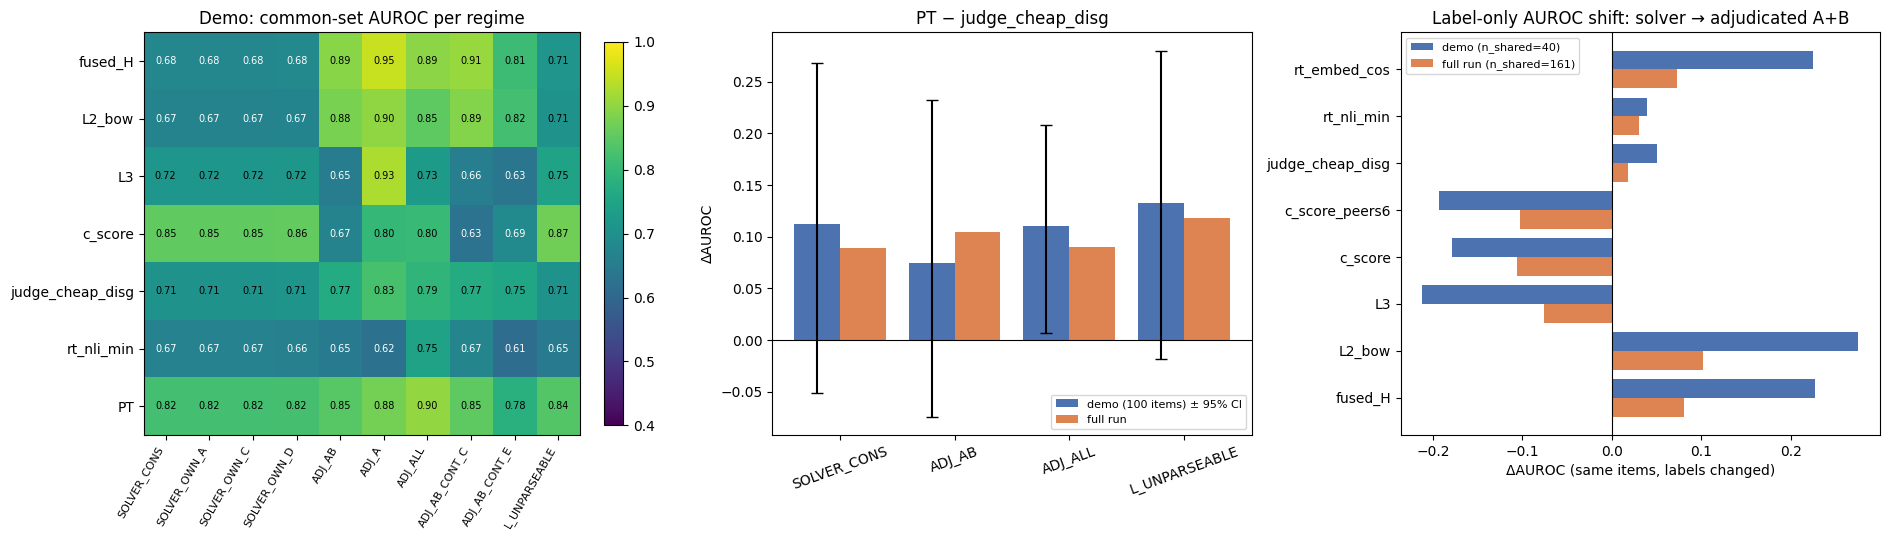

In [27]:
_short = lambda r: (r[2:] if r.startswith("R_") else r).replace("_AS_ERROR", "")
fig, axes = plt.subplots(1, 3, figsize=(19, 5.5))

# (1) common-set AUROC matrix for key metrics across track-L regimes
Lregs = [k for k, v in regimes.items() if v["track"] == "L"]
keym = ["p_fused_H", "bow_uncarried", "l3_score", "c_score", "judge_cheap_disg", "rt_nli_min", "PT_oof"]
Mx = r5["matrix"].loc[[m for m in keym if m in r5["matrix"].index], Lregs]
im = axes[0].imshow(Mx.values.astype(float), cmap="viridis", vmin=0.4, vmax=1.0, aspect="auto")
axes[0].set_xticks(range(len(Lregs)), [_short(r) for r in Lregs], rotation=60, ha="right", fontsize=8)
axes[0].set_yticks(range(len(Mx.index)), [nice(m) for m in Mx.index])
for i in range(Mx.shape[0]):
    for j in range(Mx.shape[1]):
        v = Mx.values[i, j]
        if not pd.isna(v):
            axes[0].text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=7, color="w" if v < 0.7 else "k")
axes[0].set_title("Demo: common-set AUROC per regime")
fig.colorbar(im, ax=axes[0], fraction=0.04)

# (2) PT - judge per regime: demo (with CI) vs full run
rr = [rn for rn in ("R_SOLVER_CONS", "R_ADJ_AB", "R_ADJ_ALL", "L_UNPARSEABLE_AS_ERROR") if "delta_PT_oof_vs_judge_cheap_disg" in ptp.get(rn, {})]
dv = [ptp[rn]["delta_PT_oof_vs_judge_cheap_disg"]["delta"] for rn in rr]
ci = [ptp[rn]["delta_PT_oof_vs_judge_cheap_disg"]["ci"] for rn in rr]
x = np.arange(len(rr))
axes[1].bar(x - 0.2, dv, 0.4, yerr=[[d - (c[0] if c[0] is not None else d) for d, c in zip(dv, ci)], [(c[1] if c[1] is not None else d) - d for d, c in zip(dv, ci)]],
            capsize=4, label="demo (100 items) ± 95% CI", color="#4C72B0")
axes[1].bar(x + 0.2, [ref["PT_minus_judge_cheap_disg"][rn] for rn in rr], 0.4, label="full run", color="#DD8452")
axes[1].axhline(0, color="k", lw=0.8)
axes[1].set_xticks(x, [_short(r) for r in rr], rotation=20)
axes[1].set_ylabel("ΔAUROC"); axes[1].set_title("PT − judge_cheap_disg"); axes[1].legend(fontsize=8)

# (3) label-only shift solver-consistent -> adjudicated A+B
SH = r5["shift"]
sh = SH[(SH["from"] == "R_SOLVER_CONS") & (SH["to"] == "R_ADJ_AB")] if len(SH) else SH
if len(sh):
    sh = sh.set_index("metric").reindex([nice(m) for m in ["p_fused_H", "bow_uncarried", "l3_score", "c_score", "c_score_peers6", "judge_cheap_disg", "rt_nli_min", "rt_embed_cos"]]).dropna(subset=["label_only_shift"])
    y_ = np.arange(len(sh))
    axes[2].barh(y_ + 0.2, sh.label_only_shift, 0.4, color="#4C72B0", label=f"demo (n_shared={int(sh.n_shared.iloc[0])})")
    axes[2].barh(y_ - 0.2, [ref["label_only_shift_SOLVER_CONS_to_ADJ_AB"].get(m, np.nan) for m in sh.index], 0.4, color="#DD8452", label="full run (n_shared=161)")
    axes[2].set_yticks(y_, sh.index); axes[2].axvline(0, color="k", lw=0.8)
    axes[2].legend(fontsize=8)
else:
    axes[2].text(0.5, 0.5, "too few shared items", ha="center")
axes[2].set_title("Label-only AUROC shift: solver → adjudicated A+B"); axes[2].set_xlabel("ΔAUROC (same items, labels changed)")
plt.tight_layout(); plt.show()